# Sentiment Analysis: Social Media Discourse
**Pure Python Pipeline | VADER + Rule-Based NLP | CSV Workflow**

---

## Background
This notebook performs sentiment analysis on publicly scraped social media posts (X/Twitter, Reddit, Instagram, TikTok, forums, etc.). It uses **VADER** for compound sentiment scoring combined with rule-based preprocessing including slang normalization, stopword filtering, and lemmatization.

---

## Analytical Workflow
| Step | Stage | Description |
|------|-------|-------------|
| 1 | **Configuration** | Set CSV path, column names, thresholds |
| 2 | **Data Loading** | Load and validate CSV locally |
| 3 | **Preprocessing** | Clean text, normalize slang, tokenize, lemmatize |
| 4 | **VADER Sentiment** | Score and label each post (Positive / Neutral / Negative) |
| 5 | **Feature Engineering** | Text length features for EDA |
| 6 | **Visualizations** | Dashboard, distributions, keywords, n-grams, word clouds, time trends |
| 7 | **Export** | Save enriched CSV |
| 8 | **Summary Report** | Print final statistics |


---
# 0. Install Dependencies

In [1]:
# Run once to install required packages
!pip install vaderSentiment wordcloud nltk emoji textblob textstat -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 34.4 MB/s eta 0:00:00


---
# 1. Imports & Global Setup

In [2]:
import os
import re
import string
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

import nltk
import emoji
from dateutil import parser as dateutil_parser

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import ngrams

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud

# NLTK Resources
for resource in ["punkt", "stopwords", "wordnet", "omw-1.4"]:
    nltk.download(resource, quiet=True)

# Plot Style Configuration
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)

plt.rcParams.update({
    "figure.facecolor": "#fafafa",
    "axes.facecolor": "#fafafa",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Color Palette
PALETTE = {
    "positive": "#2ecc71",
    "neutral": "#3498db",
    "negative": "#e74c3c",
}

# Output Directory Setup
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("All imports loaded successfully.")

All imports loaded successfully.


---
# 2. Configuration

Edit the values below to match your dataset.

In [3]:
# Input
CSV_PATH    = "Epstein_Files_Concatenated.csv"    # Path to your CSV file
TEXT_COLUMN = "full_text"             # Column containing the post text
DATE_COLUMN = "created_at"     # Datetime column — set to None to skip time-series

# Sampling
SAMPLE_SIZE = None               # Integer to subsample, or None for full dataset

# Sentiment thresholds (VADER compound score)
POSITIVE_THRESHOLD =  0.10
NEGATIVE_THRESHOLD = -0.10

print("Configuration loaded.")

Configuration loaded.


In [4]:
# Robust multi-format datetime parser
def _parse_single_date(val):
    """Parse one value: ISO, DD/MM/YYYY, Unix timestamps (s/ms), Twitter fmt, etc."""
    if val is None or (isinstance(val, float) and pd.isna(val)):
        return pd.NaT
    val_str = str(val).strip()
    # Purely numeric -> Unix timestamp
    if val_str.lstrip("-").isdigit():
        ts   = float(val_str)
        unit = "ms" if ts > 1e12 else "s"
        try:
            return pd.to_datetime(ts, unit=unit, utc=True).tz_localize(None)
        except Exception:
            return pd.NaT
    # Text date -> dateutil
    try:
        parsed = dateutil_parser.parse(val_str, fuzzy=True)
        return pd.Timestamp(parsed).replace(tzinfo=None)
    except Exception:
        return pd.NaT

def parse_datetime_robust(series):
    """
    Parse a datetime column regardless of format. Always returns tz-naive timestamps.
    Fast-path: vectorized pd.to_datetime for standard formats.
    Slow-path: element-wise dateutil for everything else.
    """
    try:
        parsed = pd.to_datetime(series, errors="coerce", utc=True)
        if parsed.notna().mean() >= 0.5:
            return parsed.dt.tz_convert("UTC").dt.tz_localize(None)
    except Exception:
        pass
    return series.apply(_parse_single_date)

print("Robust datetime parser defined.")

Robust datetime parser defined.


---
# 3. Data Loading

In [5]:
# Validate file
if not os.path.isfile(CSV_PATH):
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}")

df = pd.read_csv(CSV_PATH)

if TEXT_COLUMN not in df.columns:
    raise ValueError(f'Column "{TEXT_COLUMN}" not found. Available: {list(df.columns)}')

# Standardize column name to 'text'
df = (
    df.dropna(subset=[TEXT_COLUMN])
      .rename(columns={TEXT_COLUMN: "text"})
      .reset_index(drop=True)
)

# Optional sampling
if SAMPLE_SIZE and SAMPLE_SIZE < len(df):
    df = df.sample(SAMPLE_SIZE, random_state=42).reset_index(drop=True)
    print(f"Sampled {SAMPLE_SIZE:,} rows.")

# Parse datetime with robust multi-format parser
if DATE_COLUMN and DATE_COLUMN in df.columns:
    df["created_at"] = parse_datetime_robust(df[DATE_COLUMN].astype(str))
    valid_dates = df["created_at"].notna().sum()
    if valid_dates > 0:
        print(f"Date range  : {df['created_at'].min()} -> {df['created_at'].max()}")
        print(f"Parsed      : {valid_dates:,} / {len(df):,} valid dates")
    else:
        print(f'Warning: could not parse DATE_COLUMN="{DATE_COLUMN}". Time-series disabled.')
elif DATE_COLUMN:
    print(f'Note: DATE_COLUMN="{DATE_COLUMN}" not found in CSV. Time-series skipped.')

print(f"Loaded      : {len(df):,} rows")
print(f"Columns     : {list(df.columns)}")
df.head(3)

Date range  : 2025-11-01 00:24:57 -> 2026-03-12 12:59:03
Parsed      : 3,261 / 3,261 valid dates
Loaded      : 3,261 rows
Columns     : ['conversation_id_str', 'created_at', 'favorite_count', 'text', 'id_str', 'image_url', 'in_reply_to_screen_name', 'lang', 'location', 'quote_count', 'reply_count', 'retweet_count', 'tweet_url', 'user_id_str', 'username']


,conversation_id_str,created_at,favorite_count,text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,2030857967696785851,2026-03-10 23:59:06,0,@sploder6 @DavidNachman3 @59SouthLee @BackupJe...,2031520251653865520,NaN,sploder6,en,NaN,0,1,0,https://x.com/undefined/status/203152025165386...,1720665183188922368,NaN
1,2031479426836316296,2026-03-10 23:58:47,0,@Israel2252 Not all Jews but all Zionists are ...,2031520170703798651,NaN,Israel2252,en,NaN,0,0,0,https://x.com/undefined/status/203152017070379...,2845845628,NaN
2,2031217139353309554,2026-03-10 23:56:45,0,@Parodyjeffx # I @realDonaldTrump wants the Am...,2031519658818548209,NaN,Parodyjeffx,en,NaN,0,0,0,https://x.com/undefined/status/203151965881854...,229414949,NaN


In [6]:
# Initial Data Profile
print("Before Cleaning")

df = df.copy()
initial_shape = len(df)

print(f"Shape           : {df.shape}")
print(f"Null texts      : {df['text'].isna().sum()}")
print(f"Duplicate texts : {df['text'].duplicated().sum()}")

print("\nSample posts:")
for i, txt in enumerate(df["text"].dropna().head(3), 1):
    print(f"  [{i}] {str(txt)[:150]}")

# Deep normalization for robust deduplication:
# lowercase, collapse whitespace, strip URLs/mentions/hashtags/punctuation
import re as _re_dedup
import string as _string_dedup

def _deep_norm(text):
    t = str(text).lower()
    t = _re_dedup.sub(r"http\S+|www\.\S+", " ", t)       # URLs
    t = _re_dedup.sub(r"@[A-Za-z0-9_.]+", " ", t)        # mentions
    t = _re_dedup.sub(r"#[A-Za-z0-9_]+", " ", t)         # hashtags
    t = t.translate(str.maketrans("", "", _string_dedup.punctuation))  # punctuation
    t = _re_dedup.sub(r"\s+", " ", t).strip()             # whitespace
    return t

df["text_norm"] = df["text"].apply(_deep_norm)

# Remove duplicates using deep-normalized text (catches near-duplicates)
df_clean = df.drop_duplicates(subset=["text_norm"]).copy()

# Drop nulls and empty posts
df_clean = df_clean.dropna(subset=["text"])
df_clean = df_clean[df_clean["text"].str.strip().astype(bool)].copy()

# Reassign so all downstream cells use the cleaned dataframe
df = df_clean.copy()

# Post-cleaning profile
final_shape = len(df)
removed_rows = initial_shape - final_shape

print("\nAfter Cleaning")
print(f"Shape           : {df.shape}")
print(f"Removed rows    : {removed_rows}")
print(f"Null texts      : {df['text'].isna().sum()}")
print(f"Duplicate texts : {df['text_norm'].duplicated().sum()}")

print("\nData Reduction Summary")
print(f"Before : {initial_shape:,}")
print(f"After  : {final_shape:,}")
print(f"Loss   : {removed_rows:,} ({removed_rows/initial_shape:.2%})")

# Cleanup helper column
df = df.drop(columns=["text_norm"])


Before Cleaning
Shape           : (3261, 15)
Null texts      : 0
Duplicate texts : 1110

Sample posts:
  [1] @sploder6 @DavidNachman3 @59SouthLee @BackupJeffx Epstein was Jewish. The emails show his claimed Rothschild links and social ties with figures like B
  [2] @Israel2252 Not all Jews but all Zionists are ruining the world. Example; Epstein file. 
  [3] @Parodyjeffx # I @realDonaldTrump wants the Americans to treat me the way the North Korean people treat their dictator Kim Jong Un # American will onc

After Cleaning
Shape           : (2098, 16)
Removed rows    : 1163
Null texts      : 0
Duplicate texts : 0

Data Reduction Summary
Before : 3,261
After  : 2,098
Loss   : 1,163 (35.66%)


---
# 4. Preprocessing

| Step | Process |
|------|---------|
| Clean | Remove URLs, @mentions, #hashtags, numbers, punctuation |
| Normalize | Expand common slang/abbreviations |
| Tokenize | Split into lowercase word tokens |
| Filter | Remove stopwords and short tokens |
| Lemmatize | Reduce words to base form |
| Dynamic stopwords | Auto-remove the top-N corpus-wide terms |


In [7]:
# Stopwords Setup
BASE_STOPWORDS = set(stopwords.words("english"))

CUSTOM_STOPWORDS = {
    "would", "said", "get", "one", "also", "even", "still",
    "via", "just", "like", "know", "think", "people", "time",
    "going", "want", "need", "make", "say", "really", "much",
    "many", "way",
}

PLATFORM_STOPWORDS = {
    "rt", "amp", "u", "im", "dont", "cant",
    "thats", "youre", "theyre", "weve",
    "https", "http", "co", "www",
}

ALL_STOPWORDS = BASE_STOPWORDS | CUSTOM_STOPWORDS | PLATFORM_STOPWORDS

# Slang Map
SLANG_MAP = {
    "idk": "do not know",
    "omg": "oh my god",
    "ikr": "i know right",
    "lol": "laughing",
    "wtf": "what the",
    "smh": "shaking my head",
    "tbh": "to be honest",
    "ngl": "not gonna lie",
    "bruh": "disbelief",
    "fr": "for real",
    "lowkey": "somewhat",
    "cap": "lie",
    "nocap": "no lie",
    "based": "firm opinion",
    "salty": "bitter",
    "sus": "suspicious",
    "lit": "exciting",
}

# Regex Patterns
URL_RE     = re.compile(r"http\S+|www\.\S+")
MENTION_RE = re.compile(r"@[A-Za-z0-9_\.]+")
HASHTAG_RE = re.compile(r"#[A-Za-z0-9_]+")
RT_RE      = re.compile(r"\bRT\b")
NUM_RE     = re.compile(r"\d+")
MULTI_SP   = re.compile(r"\s+")
AMP_RE     = re.compile(r"&amp;", re.IGNORECASE)   # HTML-encoded ampersand (Twitter artifact)
PUNCT_TRANS  = str.maketrans("", "", string.punctuation)
EMOJI_TAG_RE = re.compile(r":([a-z0-9_]+):")

# NLP Tools
lemmatizer = WordNetLemmatizer()

# Emoji Sentiment Mapping
EMOJI_SCORE = {
    "fire": 2,
    "heart_eyes": 2,
    "laughing": 2,
    "face_with_tears_of_joy": 2,
    "thumbs_up": 1,
    "clapping_hands": 1,
    "grinning_face": 1,

    "angry_face": -2,
    "rage": -3,
    "cry": -2,
    "loudly_crying_face": -2,
    "thumbs_down": -1,
    "broken_heart": -3,

    "neutral_face": 0
}

# Emoji Processing
def demojize_text(text):
    """Convert emoji to text tags, removing duplicate transcriptions within the same text."""
    text = emoji.demojize(text)
    seen_tags = set()

    def _replace_dedup(m):
        tag = m.group(1)
        if tag in seen_tags:
            return " "          # duplicate emoji transcription → strip it
        seen_tags.add(tag)
        return " " + tag.replace("_", " ") + " "

    text = EMOJI_TAG_RE.sub(_replace_dedup, text)
    return text

def emoji_sentiment_score(text):
    """Score emoji sentiment, counting each unique emoji only once per text."""
    text = emoji.demojize(text)
    matches = EMOJI_TAG_RE.findall(text)
    seen = set()
    score = 0
    for m in matches:
        if m not in seen:          # only score each unique emoji once
            seen.add(m)
            score += EMOJI_SCORE.get(m, 0)
    return score

# Slang Normalization
def normalize_slang(text):
    return " ".join(SLANG_MAP.get(w, w) for w in text.split())

# Token Validation
def is_valid_token(token):
    return (
        token.isalpha()
        and len(token) > 2
        and token not in ALL_STOPWORDS
    )

# Core Preprocessing Pipeline
def _dedup_consecutive(tokens):
    """Remove consecutively repeated tokens (artifact of repeated emojis).
    e.g. ["stop","stop","stop"] → ["stop"], ["face","tears","face","tears"] → ["face","tears"]
    Uses a sliding window to catch multi-word emoji phrase repetitions too.
    """
    if not tokens:
        return tokens
    result = []
    i = 0
    while i < len(tokens):
        # Try to detect a repeating phrase of length 1..4
        found_repeat = False
        for phrase_len in range(1, min(5, len(tokens) - i + 1)):
            phrase = tokens[i:i + phrase_len]
            # Count how many times this phrase repeats consecutively
            j = i + phrase_len
            repeat_count = 1
            while tokens[j:j + phrase_len] == phrase:
                repeat_count += 1
                j += phrase_len
            if repeat_count > 1:
                # Keep only one copy of the repeated phrase
                result.extend(phrase)
                i = j
                found_repeat = True
                break
        if not found_repeat:
            result.append(tokens[i])
            i += 1
    return result

def preprocess(text):
    if not isinstance(text, str) or not text.strip():
        return [], 0

    emoji_score = emoji_sentiment_score(text)

    text = demojize_text(text)
    text = URL_RE.sub(" ", text)
    text = MENTION_RE.sub(" ", text)
    text = HASHTAG_RE.sub(" ", text)
    text = RT_RE.sub(" ", text)
    text = NUM_RE.sub(" ", text)

    text = text.replace("\n", " ").translate(PUNCT_TRANS).lower()
    text = MULTI_SP.sub(" ", text).strip()

    text = normalize_slang(text)

    tokens = re.findall(r"\b[a-z]+\b", text)

    # POS-aware lemmatization: map Penn Treebank tags → WordNet POS
    # so "arrested"→"arrest", "arresting"→"arrest", "visions"→"vision"
    # This prevents inflected forms of the same word becoming different tokens
    # and producing false n-gram repeats like "arrest arresting".
    def _penn_to_wn(tag):
        if tag.startswith('J'): return 'a'   # adjective
        if tag.startswith('V'): return 'v'   # verb
        if tag.startswith('N'): return 'n'   # noun
        if tag.startswith('R'): return 'r'   # adverb
        return 'n'                            # default noun

    raw_valid = [t for t in tokens if is_valid_token(t)]
    try:
        import nltk as _nltk
        pos_tagged = _nltk.pos_tag(raw_valid)
        clean_tokens = [
            lemmatizer.lemmatize(word, pos=_penn_to_wn(tag))
            for word, tag in pos_tagged
        ]
    except Exception:
        # Fallback: default lemmatization without POS
        clean_tokens = [lemmatizer.lemmatize(t) for t in raw_valid]

    # Remove consecutive repeated tokens caused by:
    # (a) repeated emojis:  🛑🛑🛑 → ["stop","stop","stop"] → ["stop"]
    # (b) POS-collapsed inflections: "arrested arresting" → ["arrest","arrest"] → ["arrest"]
    clean_tokens = _dedup_consecutive(clean_tokens)

    # Final dedup: remove any remaining within-post token duplicates globally
    # Preserves first occurrence order — prevents any repeat bigrams/trigrams
    seen_in_post = set()
    deduped_final = []
    for tok in clean_tokens:
        if tok not in seen_in_post:
            seen_in_post.add(tok)
            deduped_final.append(tok)
    clean_tokens = deduped_final

    return clean_tokens, emoji_score

# Dataset Processor
def process_dataframe(df, text_col="text"):
    results = []

    for text in df[text_col]:
        tokens, emo_score = preprocess(text)

        results.append({
            "original_text": text,
            "clean_tokens": tokens,
            "emoji_score": emo_score,
            "token_count": len(tokens)
        })

    return pd.DataFrame(results)

## 3a. Name Anonymization

Automatically replaces detected person names (NER via NLTK) with a `[PERSON]` placeholder before sentiment scoring. This protects privacy and prevents personal names from skewing keyword/word-cloud analysis.

In [8]:
import nltk
import re as _re

# Correct NLTK resource names for named-entity recognition
for _res in ["punkt", "punkt_tab", "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng",
             "maxent_ne_chunker", "words"]:
    nltk.download(_res, quiet=True)

# ── Regex-based name list (fast, zero-dependency fallback) ────────────────
_COMMON_NAMES = {
    # NBA / Sports Core
    "lebron","james","anthony","davis","draymond","green","steph","curry","stephen","kevin","durant",
    "kobe","bryant","shaquille","oneal","michael","jordan","magic","johnson","larry","bird",
    "charles","barkley","tim","duncan","kawhi","leonard","giannis","antetokounmpo",
    "nikola","jokic","joel","embiid","luka","doncic","jayson","tatum","devin","booker",
    "ja","morant","zion","williamson","donovan","mitchell","trae","young","paul","george",
    "russell","westbrook","chris","paul","kyrie","irving","jimmy","butler","bam","adebayo",
    "anthony","edwards","paolo","banchero","victor","wembanyama","domantas","sabonis",
    "deaaron","fox","damian","lillard","cj","mccollum",

    # NBA Coaches / Execs
    "adam","silver","mark","jackson","mike","brown","steve","kerr","erik","spoelstra",
    "nick","nurse","tyronn","lue","jason","kidd","monty","williams","quin","snyder",
    "gregg","popovich",

    # NFL Players / Coaches (high frequency in sentiment data)
    "tom","brady","patrick","mahomes","aaron","rodgers","josh","allen","joe","burrow",
    "jalen","hurts","dak","prescott","lamar","jackson","justin","herbert","baker","mayfield",
    "sean","mcdermott","bill","belichick",

    # MLB / Other Sports
    "shohei","ohtani","aaron","judge","mike","trout","fernando","tatis","mookie","betts",

    # US Presidents / Politics
    "joe","biden","donald","trump","barack","obama","george","bush","bill","clinton",
    "kamala","harris","hillary","clinton","bernie","sanders","nancy","pelosi","mitch","mcconnell",
    "alexandria","ocasio","cortez","ted","cruz","marco","rubio","rand","paul","elizabeth","warren",

    # Supreme Court / Government
    "john","roberts","clarence","thomas","sonia","sotomayor","elena","kagan",
    "amy","coney","barrett","samuel","alito",

    # Tech / Business Leaders
    "elon","musk","jeff","bezos","mark","zuckerberg","bill","gates","steve","jobs",
    "sundar","pichai","tim","cook","linda","yaccarino","satya","nadella","larry","page","sergey","brin",

    # Entertainment / Media Celebrities
    "taylor","swift","beyonce","rihanna","drake","kanye","west","kim","kardashian",
    "kendall","jenner","kylie","jenner","leonardo","dicaprio","brad","pitt","angelina","jolie",
    "johnny","depp","tom","cruise","will","smith","dwayne","johnson","ryan","reynolds",
    "scarlett","johansson","morgan","freeman","robert","downey","jr",

    # Journalists / Media / Influence
    "tucker","carlson","anderson","cooper","don","lemon","megyn","kelly","rachel","maddow",

    # Common Male Names (expanded)
    "james","john","robert","michael","william","richard","joseph","thomas","charles",
    "david","daniel","matthew","andrew","joshua","ryan","brandon","jason","justin",
    "peter","brian","eric","adam","scott","steven","timothy","kevin","aaron","benjamin",
    "samuel","patrick","cameron","nathan","zachary","alexander","ethan","noah","logan",
    "jacob","hunter","tyler","carter","wyatt","colton","dylan","carson","julian","grayson","baron",
    "epstein","jack","smith","davis"

    # Common Female Names (expanded)
    "mary","patricia","jennifer","linda","barbara","elizabeth","susan","jessica","sarah",
    "karen","lisa","nancy","betty","margaret","sandra","ashley","emily","amanda","melissa",
    "helen","donna","ruth","sharon","michelle","kimberly","deborah","dorothy","amy","angela",
    "anna","brittany","nicole","samantha","christine","catherine","victoria","rebecca",
    "madison","olivia","ava","isabella","mia","charlotte","amelia","harper","evelyn",
    "abigail","ella","scarlett","grace","chloe","zoe","penelope","lily","hannah","leah",

    # High Ambiguity Single Tokens (important NLP noise blockers)
    "young","green","brown","white","black","gray","king","queen","prince","priest","judge",
    "davis","walker","turner","scott","bell","ross","reed","cooper","brooks","morgan","jordan","de",
    "da", "di", "del", "della", "der", "den","van", "von", "zu", "zum", "zur","la", "le", "du", "des",
    "dos", "das","bin", "bint","al", "el", "ibn", "abu","mac", "mc", "o", "fitz"
}

TITLE_NAME_RE = re.compile(
    r"\b(Mr\.?|Mrs\.?|Ms\.?|Dr\.?|Prof\.?)\s+([A-Z][a-z]+(?:\s+[A-Z][a-z]+){0,2})",
    re.UNICODE,
)

# Only match REALISTIC full names (reduce false positives like "New York")
FULL_NAME_RE = re.compile(
    r"\b([A-Z][a-z]{2,20})\s+([A-Z][a-z]{2,20})\b"
)

# Optional: detect social handles
HANDLE_RE = re.compile(r"@[a-zA-Z0-9_\.]+")


def _regex_remove(text: str) -> str:
    """Remove titles, handles, and known-name entities safely."""

    # Step 1: Remove handles first (important for noise control)
    text = HANDLE_RE.sub("", text)

    # Step 2: Remove title + name patterns
    text = TITLE_NAME_RE.sub("", text)

    def _remove_if_known(match):
        first = match.group(1).lower()
        last = match.group(2).lower()

        # Stronger condition: remove if EITHER token is known OR both look like common names
        if first in _COMMON_NAMES or last in _COMMON_NAMES:
            return ""

        return match.group(0)

    # Step 3: Clean full names
    text = FULL_NAME_RE.sub(_remove_if_known, text)

    # Step 4: Normalize extra spaces caused by removals
    text = re.sub(r"\s{2,}", " ", text).strip()

    return text

def _nltk_remove(text: str) -> str:
    """NLTK NER pass: remove PERSON entities the regex missed."""
    try:
        tokens   = nltk.word_tokenize(text)
        pos_tags = nltk.pos_tag(tokens)
        tree     = nltk.ne_chunk(pos_tags, binary=False)
        result   = []
        for subtree in tree:
            if hasattr(subtree, "label") and subtree.label() == "PERSON":
                pass  # drop the name entirely
            elif hasattr(subtree, "label"):
                result.extend(word for word, _ in subtree.leaves())
            else:
                result.append(subtree[0])
        return " ".join(result)
    except Exception:
        return text

def anonymize_names(text: str) -> str:
    """
    Two-stage name REMOVAL pipeline (names are deleted, not replaced):
      1. Regex pass  — removes titles + known athlete/common names
      2. NLTK NER    — removes novel capitalized proper names
    Cleans up any double spaces left after deletion.
    """
    if not isinstance(text, str) or not text.strip():
        return text
    text = _regex_remove(text)
    text = _nltk_remove(text)
    text = _re.sub(r" {2,}", " ", text).strip()
    return text

# Apply — original preserved in df["text"], cleaned in df["text_anon"]
df["text_anon"] = df["text"].apply(anonymize_names)

names_found = (df["text_anon"] != df["text"]).sum()
print(f"Name removal complete.")
print(f"Posts with names removed : {names_found:,} / {len(df):,}")
print("\nSample (original -> cleaned):")
sample_mask = df["text_anon"] != df["text"]
for _, row in df[sample_mask].head(3).iterrows():
    print(f"  ORIG : {str(row['text'])[:120]}")
    print(f"  CLEAN: {str(row['text_anon'])[:120]}")
    print()
if names_found == 0:
    print("  (No names detected, check that posts contain recognisable proper names!)")

Name removal complete.
Posts with names removed : 1,603 / 2,098

Sample (original -> cleaned):
  ORIG : @sploder6 @DavidNachman3 @59SouthLee @BackupJeffx Epstein was Jewish. The emails show his claimed Rothschild links and s
  CLEAN: Epstein was Jewish. The emails show his claimed Rothschild links and social ties with figures like Baron de Rothschild. 

  ORIG : @Israel2252 Not all Jews but all Zionists are ruining the world. Example; Epstein file. 
  CLEAN: Not all Jews but all Zionists are ruining the world. Example; Epstein file.

  ORIG : @Parodyjeffx # I @realDonaldTrump wants the Americans to treat me the way the North Korean people treat their dictator K
  CLEAN: # I wants the Americans to treat me the way the North Korean people treat their dictator Un # American will once U clear



In [9]:
# First pass: extract tokens only (ignore emoji score)
df["_tokens_tmp"] = df["text"].apply(lambda x: preprocess(x)[0])

# Flatten tokens correctly
_all_toks = [t for toks in df["_tokens_tmp"] for t in toks]

# Build dynamic stopwords safely
DYNAMIC_STOPWORDS = {
    w for w, _ in Counter(_all_toks).most_common(30)
}

ALL_STOPWORDS.update(DYNAMIC_STOPWORDS)

# Second pass: full preprocessing (tokens + emoji score)
df[["text_clean", "emoji_score"]] = df["text"].apply(
    lambda x: pd.Series(preprocess(x))
)

# Cleanup temp column
df.drop(columns=["_tokens_tmp"], inplace=True)

# Summary
valid = df["text_clean"].apply(bool).sum()

print("Preprocessing complete.")
print(f"Posts with clean tokens : {valid:,} / {len(df):,}")
print(f"Dynamic stopwords added : {len(DYNAMIC_STOPWORDS)}")

df[["text", "text_clean", "emoji_score"]].head(3)

Preprocessing complete.
Posts with clean tokens : 2,091 / 2,098
Dynamic stopwords added : 30


,text,text_clean,emoji_score
0,@sploder6 @DavidNachman3 @59SouthLee @BackupJe...,"[jewish, email, claim, rothschild, link, socia...",0
1,@Israel2252 Not all Jews but all Zionists are ...,"[jew, zionist, ruin, world, example]",0
2,@Parodyjeffx # I @realDonaldTrump wants the Am...,"[want, american, treat, north, korean, dictato...",0


---
# 5. Sentiment Scoring (VADER)

Add any words that appear too frequently and skew the sentiment analysis into `BIAS_WORDS` below.
Leave the set empty `set()` to skip filtering entirely.

These words will be silently stripped from `text_clean` before scoring — they won't appear in word clouds, keyword charts, or n-gram analysis either.

In [10]:
# ── Bias Word Filter ─────────────────────────────────────────────────────
# Add lowercase words you want to remove before sentiment scoring.
# These are typically over-represented topic words that bias the analysis
# (e.g. the subject of the dataset itself).
# Leave as set() to skip filtering.

BIAS_WORDS = {
    # "lakers", "nba", "game",   ← example: uncomment and edit as needed
    "file","cry","hand"
}

# ─────────────────────────────────────────────────────────────────────────
if BIAS_WORDS:
    _bias_lower = {w.lower() for w in BIAS_WORDS}
    before = df["text_clean"].apply(len).sum()
    df["text_clean"] = df["text_clean"].apply(
        lambda toks: [t for t in toks if t.lower() not in _bias_lower]
    )
    after = df["text_clean"].apply(len).sum()
    removed = before - after
    print(f"Bias filter applied.")
    print(f"Words removed : {removed:,} tokens across {len(df):,} posts")
    print(f"Filtered words: {sorted(_bias_lower)}")
else:
    print("Bias filter : inactive (BIAS_WORDS is empty — add words above to enable)")

Bias filter applied.
Words removed : 1,752 tokens across 2,098 posts
Filtered words: ['cry', 'file', 'hand']


In [11]:
analyzer = SentimentIntensityAnalyzer()

# Auto Noise Filter
# Automatically builds a set of low-value words to strip before scoring.
# Combines POS fillers, frequency-based noise, and sentiment-neutral words.

FREQ_THRESHOLD = 0.70
NEUTRAL_THRESHOLD = 0.02   # Lowered: 0.05 was too aggressive, stripped sentiment words

# POS Tag Setup
import nltk
nltk.download("averaged_perceptron_tagger_eng", quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)

FILLER_POS = {
    "PRP", "PRP$", "DT", "CC", "IN", "WP", "WDT",
    "WRB", "EX", "RP", "UH", "MD",
}

EXTRA_FILLERS = {
    "ok", "okay", "yeah", "yep", "nope", "hm", "hmm", "uh", "um",
    "gonna", "gotta", "wanna", "ima", "tho", "tis", "twas",
    "w", "b", "c", "d", "e", "f", "g", "h", "j", "k", "l", "m",
    "n", "o", "p", "q", "r", "s", "t", "v", "x", "y", "z",
    "lol", "haha", "hehe", "lmao", "rofl",
}

# POS-Based Filler Extraction
def _pos_filler_words(corpus_tokens: list[list]) -> set:
    import random
    from collections import Counter, defaultdict

    sample = corpus_tokens[:3000]
    flat = [t for toks in sample for t in toks]

    try:
        tagged = nltk.pos_tag(flat)
    except Exception:
        return set()

    pos_map = defaultdict(Counter)
    for word, pos in tagged:
        pos_map[word.lower()][pos] += 1

    return {
        word
        for word, counts in pos_map.items()
        if counts.most_common(1)[0][0] in FILLER_POS
    }

# Frequency-Based Noise
def _high_freq_words(corpus_tokens: list[list], threshold: float) -> set:
    from collections import Counter

    n_docs = len(corpus_tokens)
    doc_freq = Counter()

    for toks in corpus_tokens:
        for w in set(toks):
            doc_freq[w] += 1

    return {
        w for w, c in doc_freq.items()
        if c / n_docs > threshold
    }

# Sentiment Neutral Words
# Note: Single-word VADER scores are unreliable for context-dependent intensifiers
# (e.g. "absolutely", "completely" score 0.0 alone but boost sentiment in context).
# We protect known intensifiers/sentiment words from removal.
SENTIMENT_SAFE = {
    # Intensifiers that boost sentiment in context
    "absolutely", "completely", "totally", "utterly", "deeply", "truly",
    "seriously", "incredibly", "extremely", "highly", "terribly",
    "awful", "horrible", "terrible", "dreadful", "appalling",
    "wonderful", "fantastic", "brilliant", "excellent", "outstanding",
    "absurd", "ridiculous", "disgusting", "outrageous", "shocking",
    "amazing", "stunning", "astonishing", "devastating",
    # Negations (critical for VADER)
    "not", "never", "neither", "nobody", "nothing", "nowhere",
    "no", "nor", "hardly", "barely", "scarcely",
    # Strong opinion words
    "worst", "best", "greatest", "biggest", "most", "least",
    "always", "every", "everyone", "everywhere",
}

def _neutral_words(corpus_tokens: list[list], threshold: float) -> set:
    from collections import defaultdict

    vocab = {w for toks in corpus_tokens for w in toks}
    scores = defaultdict(list)

    for word in vocab:
        sc = analyzer.polarity_scores(word)["compound"]
        scores[word].append(abs(sc))

    return {
        w for w, vals in scores.items()
        if sum(vals) / len(vals) < threshold
        and w not in SENTIMENT_SAFE       # never strip known sentiment words
        and len(w) > 2                    # never strip very short words blindly
    }

# Build Auto Noise Dictionary
corpus_tokens = df["text_clean"].tolist()

print("Building auto noise filter...")

layer1 = _pos_filler_words(corpus_tokens) | EXTRA_FILLERS
print(f"Layer 1 POS fillers        : {len(layer1):,}")

layer2 = set()
if FREQ_THRESHOLD is not None:
    layer2 = _high_freq_words(corpus_tokens, FREQ_THRESHOLD)
    print(f"Layer 2 high freq words    : {len(layer2):,}")

layer3 = set()
if NEUTRAL_THRESHOLD is not None:
    layer3 = _neutral_words(corpus_tokens, NEUTRAL_THRESHOLD)
    print(f"Layer 3 neutral words      : {len(layer3):,}")

AUTO_NOISE = layer1 | layer2 | layer3

print("-" * 45)
print(f"Total AUTO_NOISE words     : {len(AUTO_NOISE):,}")

# Apply Noise Filter
before_tokens = df["text_clean"].apply(len).sum()

df["text_clean"] = df["text_clean"].apply(
    lambda toks: [t for t in toks if t.lower() not in AUTO_NOISE]
)

after_tokens = df["text_clean"].apply(len).sum()

print(f"Tokens removed             : {before_tokens - after_tokens:,}")
print("\nSample noise words:")
print(sorted(list(AUTO_NOISE))[:30])

# Light Clean for VADER
def _light_clean(text: str) -> str:
    text = URL_RE.sub(" ", text)
    text = MENTION_RE.sub(" ", text)
    text = HASHTAG_RE.sub(" ", text)
    text = AMP_RE.sub("and", text)
    text = MULTI_SP.sub(" ", text)

    _strip = AUTO_NOISE | ({w.lower() for w in BIAS_WORDS} if "BIAS_WORDS" in globals() else set())

    return " ".join(w for w in text.split() if w.lower() not in _strip).strip()

# Sentiment Scoring
def score_sentiment(tokens: list, original_text: str = ""):
    if not tokens:
        return 0.0, "neutral", 0.0, 0.0, 0.0

    s1 = analyzer.polarity_scores(" ".join(tokens))
    c1 = s1["compound"]

    if original_text:
        light = _light_clean(original_text)
        s2 = analyzer.polarity_scores(light)

        compound = 0.6 * s2["compound"] + 0.4 * c1
        pos = 0.6 * s2["pos"] + 0.4 * s1["pos"]
        neu = 0.6 * s2["neu"] + 0.4 * s1["neu"]
        neg = 0.6 * s2["neg"] + 0.4 * s1["neg"]
    else:
        compound, pos, neu, neg = c1, s1["pos"], s1["neu"], s1["neg"]

    if compound >= POSITIVE_THRESHOLD:
        label = "positive"
    elif compound <= (NEGATIVE_THRESHOLD - 0.05):
        label = "negative"
    else:
        label = "neutral"

    return round(compound, 4), label, round(pos, 4), round(neu, 4), round(neg, 4)

# Apply Scoring
df[["polarity_score", "polarity", "vader_pos", "vader_neu", "vader_neg"]] = (
    df.apply(
        lambda row: pd.Series(
            score_sentiment(
                row["text_clean"],
                row.get("text_anon", row["text"])
            )
        ),
        axis=1
    )
)

# Summary Output
summary = (
    df["polarity"]
    .value_counts()
    .rename_axis("Sentiment")
    .to_frame("Count")
    .join(
        df["polarity"]
        .value_counts(normalize=True)
        .mul(100)
        .round(1)
        .rename("Percent (%)")
    )
)

print("\nSentiment Distribution:")
print(summary.to_string())

Building auto noise filter...
Layer 1 POS fillers        : 151
Layer 2 high freq words    : 0
Layer 3 neutral words      : 4,925
---------------------------------------------
Total AUTO_NOISE words     : 4,977
Tokens removed             : 19,748

Sample noise words:
['aandacht', 'aapki', 'aaron', 'abc', 'abcd', 'abductionremoval', 'aber', 'abet', 'abgedroschen', 'able', 'aboit', 'abortion', 'abrego', 'absence', 'absolute', 'abusati', 'abusetrafficking', 'aby', 'aca', 'accept', 'access', 'accessible', 'accommodation', 'accompany', 'accord', 'account', 'accountability', 'accountable', 'accountant', 'accruing']

Sentiment Distribution:
           Count  Percent (%)
Sentiment                    
negative     996         47.5
neutral      654         31.2
positive     448         21.4


---
# 6. Feature Engineering

In [12]:
df["char_length"] = df["text"].str.len()
df["word_length"] = df["text_clean"].apply(len)
df["avg_word_len"] = df["text_clean"].apply(
    lambda toks: round(np.mean([len(t) for t in toks]), 2) if toks else 0.0
)

print(f"Features added. DataFrame shape: {df.shape}")
df[["text", "text_clean", "polarity", "polarity_score", "char_length", "word_length"]].head(5)

Features added. DataFrame shape: (2098, 26)


,text,text_clean,polarity,polarity_score,char_length,word_length
0,@sploder6 @DavidNachman3 @59SouthLee @BackupJe...,[],neutral,0.0000,324,0
1,@Israel2252 Not all Jews but all Zionists are ...,[ruin],negative,-0.4511,88,1
2,@Parodyjeffx # I @realDonaldTrump wants the Am...,"[want, treat, clear]",positive,0.7467,265,3
3,@DickSinnya @NicholasGuyatt Typical Yankee Doo...,[good],positive,0.4404,139,1
4,@jacksonhinklle My heart is broken. America ki...,"[heart, kill, pervert, devil, go, killer, die]",negative,-0.9681,262,7


---
# 6b. NLP Feature Engineering

| Feature | Description |
|---------|-------------|
| `pos_adj_ratio` | Proportion of adjectives — high → opinionated language |
| `pos_verb_ratio` | Proportion of verbs — high → action/event-focused language |
| `pos_noun_ratio` | Proportion of nouns — high → factual/entity-focused language |
| `pos_adv_ratio` | Proportion of adverbs — high → intensified/qualified language |
| `subjectivity` | TextBlob score 0–1 (0 = objective, 1 = subjective) |
| `readability` | Flesch Reading Ease (higher = easier to read) |


In [13]:
# ── NLP Feature Engineering ────────────────────────────────────────────
# Adds POS-tag ratios, TextBlob subjectivity, and Flesch readability score
# to every post. These enrich downstream analysis without altering sentiment.

from collections import Counter as _Counter
import textstat
from textblob import TextBlob

# ── 1. POS-Tag Ratios ────────────────────────────────────────────────────
# Proportion of adjectives, verbs, nouns, and adverbs in each post's
# clean token list. Posts heavy on adjectives/adverbs tend to carry
# stronger opinion signal; verb-heavy posts are often more factual.

_NOUN_TAGS  = {"NN", "NNS", "NNP", "NNPS"}
_VERB_TAGS  = {"VB", "VBD", "VBG", "VBN", "VBP", "VBZ"}
_ADJ_TAGS   = {"JJ", "JJR", "JJS"}
_ADV_TAGS   = {"RB", "RBR", "RBS"}

def _pos_ratios(tokens):
    """Return (adj_ratio, verb_ratio, noun_ratio, adv_ratio) for a token list."""
    if not tokens:
        return 0.0, 0.0, 0.0, 0.0
    tagged = nltk.pos_tag(tokens)
    tag_counts = _Counter(tag for _, tag in tagged)
    n = len(tokens)
    adj  = sum(tag_counts[t] for t in _ADJ_TAGS)  / n
    verb = sum(tag_counts[t] for t in _VERB_TAGS) / n
    noun = sum(tag_counts[t] for t in _NOUN_TAGS) / n
    adv  = sum(tag_counts[t] for t in _ADV_TAGS)  / n
    return round(adj, 4), round(verb, 4), round(noun, 4), round(adv, 4)

print("Computing POS ratios (may take a moment)...")
pos_results = df["text_clean"].apply(_pos_ratios)
df[["pos_adj_ratio", "pos_verb_ratio", "pos_noun_ratio", "pos_adv_ratio"]] = pd.DataFrame(
    pos_results.tolist(), index=df.index
)

# ── 2. TextBlob Subjectivity ─────────────────────────────────────────────
# 0.0 = very objective (factual), 1.0 = very subjective (opinion-heavy).
# Pairs well with polarity: a post can be positive AND objective (fact)
# or negative AND subjective (strong personal opinion).

df["subjectivity"] = df["text"].apply(
    lambda t: round(TextBlob(str(t)).sentiment.subjectivity, 4)
)

# ── 3. Flesch Readability Score ──────────────────────────────────────────
# Higher score = easier to read (90–100 very easy; 0–30 very hard/academic).
# Useful for detecting bot-generated or copy-pasted formal text vs.
# genuine conversational posts.

df["readability"] = df["text"].apply(
    lambda t: round(textstat.flesch_reading_ease(str(t)), 2)
)

# ── Summary ──────────────────────────────────────────────────────────────
print("NLP features added:")
print(f"  pos_adj_ratio   — mean {df['pos_adj_ratio'].mean():.3f}")
print(f"  pos_verb_ratio  — mean {df['pos_verb_ratio'].mean():.3f}")
print(f"  pos_noun_ratio  — mean {df['pos_noun_ratio'].mean():.3f}")
print(f"  pos_adv_ratio   — mean {df['pos_adv_ratio'].mean():.3f}")
print(f"  subjectivity    — mean {df['subjectivity'].mean():.3f}")
print(f"  readability     — mean {df['readability'].mean():.1f}")
print(f"DataFrame shape : {df.shape}")
df[["text", "subjectivity", "readability", "pos_adj_ratio", "polarity"]].head(3)


Computing POS ratios (may take a moment)...
NLP features added:
  pos_adj_ratio   — mean 0.146
  pos_verb_ratio  — mean 0.065
  pos_noun_ratio  — mean 0.528
  pos_adv_ratio   — mean 0.055
  subjectivity    — mean 0.363
  readability     — mean 56.7
DataFrame shape : (2098, 32)


,text,subjectivity,readability,pos_adj_ratio,polarity
0,@sploder6 @DavidNachman3 @59SouthLee @BackupJe...,0.0333,40.05,0.0000,neutral
1,@Israel2252 Not all Jews but all Zionists are ...,0.0000,66.79,0.0000,negative
2,@Parodyjeffx # I @realDonaldTrump wants the Am...,0.1611,4.65,0.6667,positive


---
# 7. Visualizations

## 7.1 Sentiment Overview Dashboard

/tmp/ipykernel_617/4022689626.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


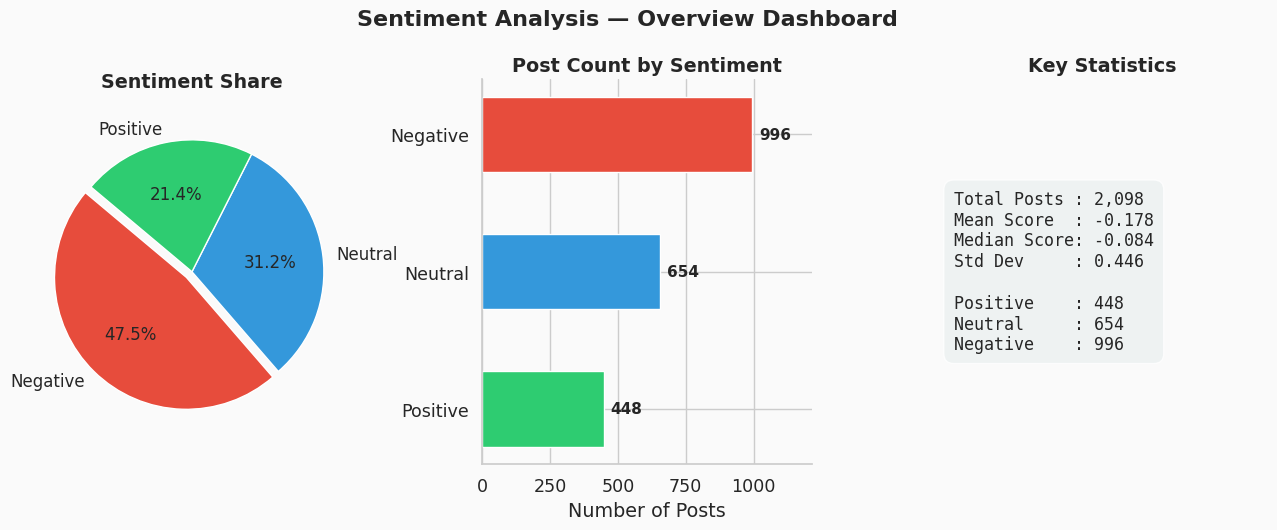

In [14]:
counts  = df["polarity"].value_counts()
ordered = ["negative", "neutral", "positive"]
sizes   = [counts.get(k, 0) for k in ordered]
colors  = [PALETTE[k] for k in ordered]

# Safe explode: avoid idxmax() crash when only 1 label exists
_nonzero  = [k for k in ordered if counts.get(k, 0) > 0]
_dominant = counts.idxmax() if len(_nonzero) > 1 else (_nonzero[0] if _nonzero else None)

# Pie: filter zero-size slices (matplotlib errors on zero-value wedges)
_pie_data   = [(s, k) for s, k in zip(sizes, ordered) if s > 0]
_pie_sizes  = [s for s, k in _pie_data]
_pie_labels = [k.capitalize() for s, k in _pie_data]
_pie_colors = [PALETTE[k] for s, k in _pie_data]
_pie_explod = [0.06 if k == _dominant else 0 for s, k in _pie_data]

fig = plt.figure(figsize=(16, 5), facecolor="#fafafa")
fig.suptitle("Sentiment Analysis — Overview Dashboard",
             fontsize=16, fontweight="bold", y=1.02)
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# Pie chart
ax1 = fig.add_subplot(gs[0])
if _pie_sizes:
    ax1.pie(
        _pie_sizes, labels=_pie_labels, colors=_pie_colors,
        autopct="%1.1f%%", explode=_pie_explod, startangle=140,
        textprops={"fontsize": 12},
    )
else:
    ax1.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax1.transAxes)
ax1.set_title("Sentiment Share", fontweight="bold", pad=14)

# Bar chart
ax2 = fig.add_subplot(gs[1])
bar_order = ordered[::-1]
bars = ax2.barh(
    [k.capitalize() for k in bar_order],
    [counts.get(k, 0) for k in bar_order],
    color=[PALETTE[k] for k in bar_order],
    edgecolor="white", height=0.55,
)
ax2.bar_label(bars, padding=5, fontsize=11, fontweight="bold")
ax2.set_title("Post Count by Sentiment", fontweight="bold")
ax2.set_xlabel("Number of Posts")
ax2.set_xlim(0, max(sizes) * 1.22 if max(sizes) else 1)

# Stats panel
ax3 = fig.add_subplot(gs[2])
ax3.axis("off")
stats_text = (
    f"Total Posts : {len(df):,}\n"
    f"Mean Score  : {df['polarity_score'].mean():.3f}\n"
    f"Median Score: {df['polarity_score'].median():.3f}\n"
    f"Std Dev     : {df['polarity_score'].std():.3f}\n\n"
    f"Positive    : {counts.get('positive', 0):,}\n"
    f"Neutral     : {counts.get('neutral', 0):,}\n"
    f"Negative    : {counts.get('negative', 0):,}"
)
ax3.text(0.05, 0.5, stats_text, transform=ax3.transAxes,
         fontsize=12, va="center", family="monospace",
         bbox=dict(boxstyle="round,pad=0.6", facecolor="#ecf0f1", alpha=0.8))
ax3.set_title("Key Statistics", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_sentiment_overview.png", dpi=150, bbox_inches="tight")
plt.show()

## 7.2 VADER Score Distribution

/tmp/ipykernel_617/2369186996.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


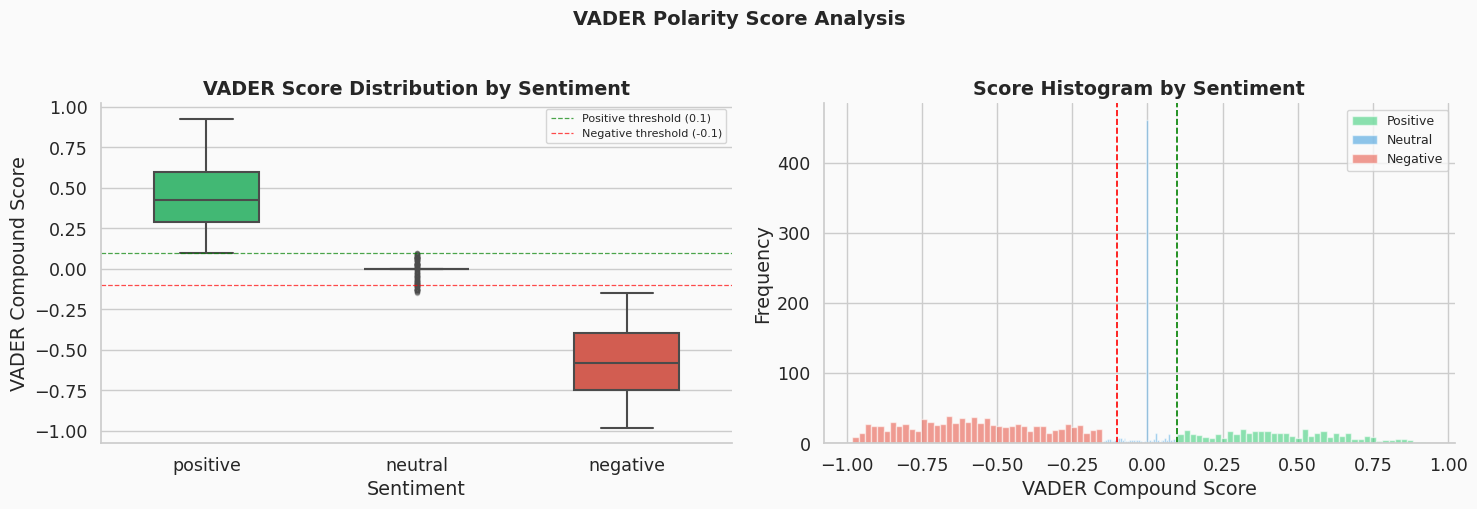

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor="#fafafa")

all_sentiments = ["positive", "neutral", "negative"]
# Only pass labels present in data so seaborn doesn't crash on empty groups
present = [s for s in all_sentiments if (df["polarity"] == s).any()]

sns.boxplot(
    data=df, x="polarity", y="polarity_score",
    order=present, palette=PALETTE, linewidth=1.5,
    ax=axes[0], width=0.5,
    flierprops=dict(marker="o", alpha=0.3, markersize=3),
)
# Annotate any missing sentiment labels
for s in all_sentiments:
    if s not in present:
        axes[0].text(0.98, 0.02, f"{s.capitalize()}: no data",
                     transform=axes[0].transAxes, fontsize=8,
                     color=PALETTE[s], ha="right", va="bottom", style="italic")
axes[0].axhline(POSITIVE_THRESHOLD, color="green", linestyle="--", linewidth=0.9, alpha=0.7,
                label=f"Positive threshold ({POSITIVE_THRESHOLD})")
axes[0].axhline(NEGATIVE_THRESHOLD, color="red", linestyle="--", linewidth=0.9, alpha=0.7,
                label=f"Negative threshold ({NEGATIVE_THRESHOLD})")
axes[0].set_title("VADER Score Distribution by Sentiment", fontweight="bold")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("VADER Compound Score")
axes[0].legend(fontsize=8)

# Histogram: always renders all 3; empty ones appear as legend entries only
for label in all_sentiments:
    subset = df[df["polarity"] == label]["polarity_score"]
    if subset.empty:
        axes[1].hist([], bins=1, alpha=0, color=PALETTE[label],
                     label=f"{label.capitalize()} (no data)")
        continue
    axes[1].hist(subset, bins=40, alpha=0.55, label=label.capitalize(),
                 color=PALETTE[label], edgecolor="white")
axes[1].axvline(POSITIVE_THRESHOLD, color="green", linestyle="--", linewidth=1.2)
axes[1].axvline(NEGATIVE_THRESHOLD, color="red",   linestyle="--", linewidth=1.2)
axes[1].set_title("Score Histogram by Sentiment", fontweight="bold")
axes[1].set_xlabel("VADER Compound Score")
axes[1].set_ylabel("Frequency")
axes[1].legend(fontsize=9)

fig.suptitle("VADER Polarity Score Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_vader_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 7.3 Top Keywords by Sentiment

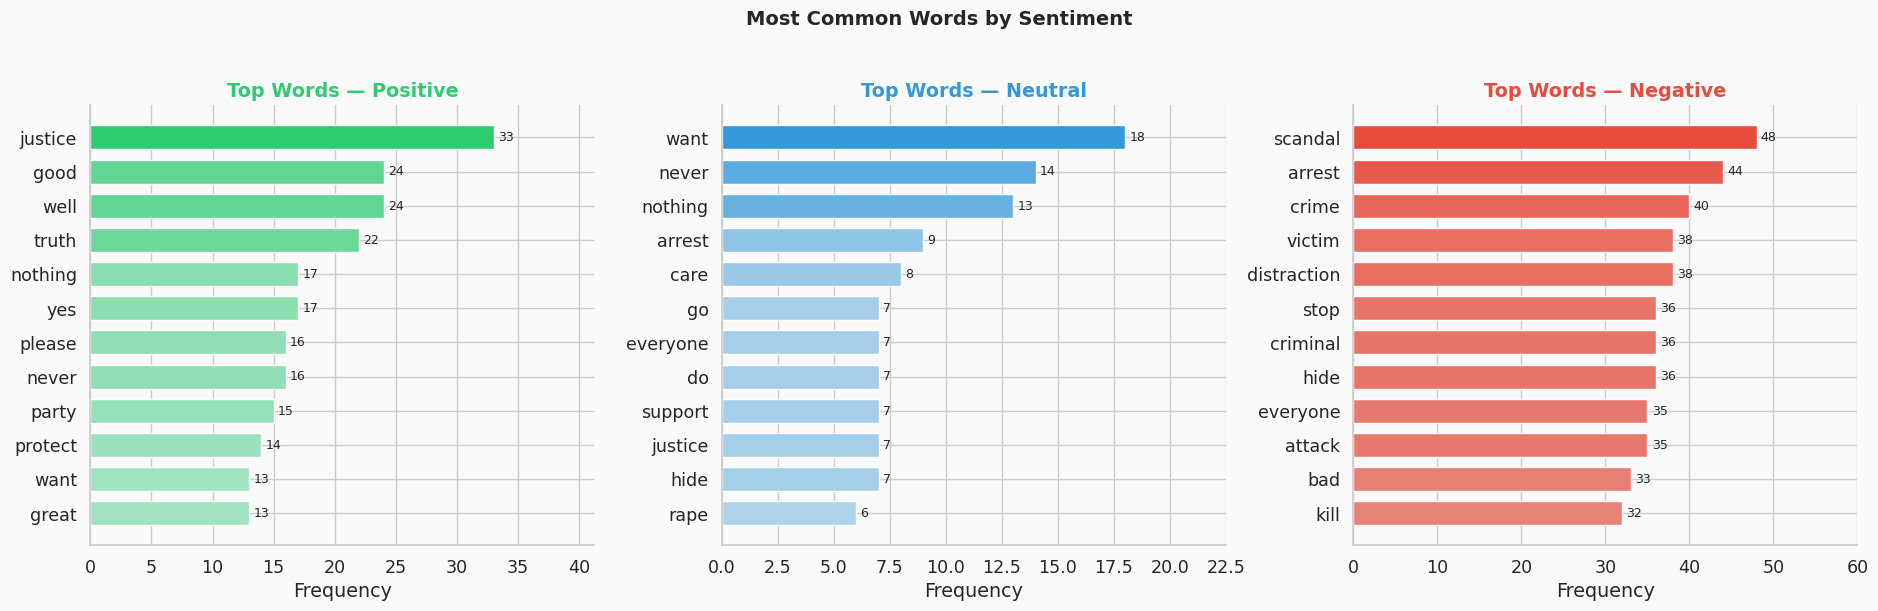

In [16]:
def get_top_words(sub_df, n=12):
    all_words = [w for toks in sub_df["text_clean"] for w in toks]
    if not all_words:
        return [], []
    top = Counter(all_words).most_common(n)
    labels, values = zip(*top)
    return list(labels), list(values)


fig, axes = plt.subplots(1, 3, figsize=(19, 6), facecolor="#fafafa")

for ax, sentiment in zip(axes, ["positive", "neutral", "negative"]):
    sub = df[df["polarity"] == sentiment]
    labels, values = get_top_words(sub)

    ax.set_title(f"Top Words — {sentiment.capitalize()}", fontweight="bold",
                 color=PALETTE[sentiment])

    if not labels:
        ax.set_facecolor("#f5f5f5")
        ax.text(0.5, 0.55, "No posts found", ha="center", va="center",
                transform=ax.transAxes, fontsize=13, color="gray")
        ax.text(0.5, 0.42, f"0 {sentiment} posts in dataset", ha="center", va="center",
                transform=ax.transAxes, fontsize=10, color="#aaaaaa", style="italic")
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values(): spine.set_visible(False)
        continue

    color = PALETTE[sentiment]
    cmap = LinearSegmentedColormap.from_list("fade", ["#ecf0f1", color])
    bar_colors = [cmap(v / max(values)) for v in values]

    bars = ax.barh(labels[::-1], values[::-1], color=bar_colors[::-1],
                   edgecolor="white", height=0.7)
    ax.bar_label(bars, padding=3, fontsize=9)
    ax.set_xlabel("Frequency")
    ax.set_xlim(0, max(values) * 1.25)

fig.suptitle("Most Common Words by Sentiment", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_top_words_by_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()

## 7.4 N-gram Analysis (Bigrams and Trigrams)

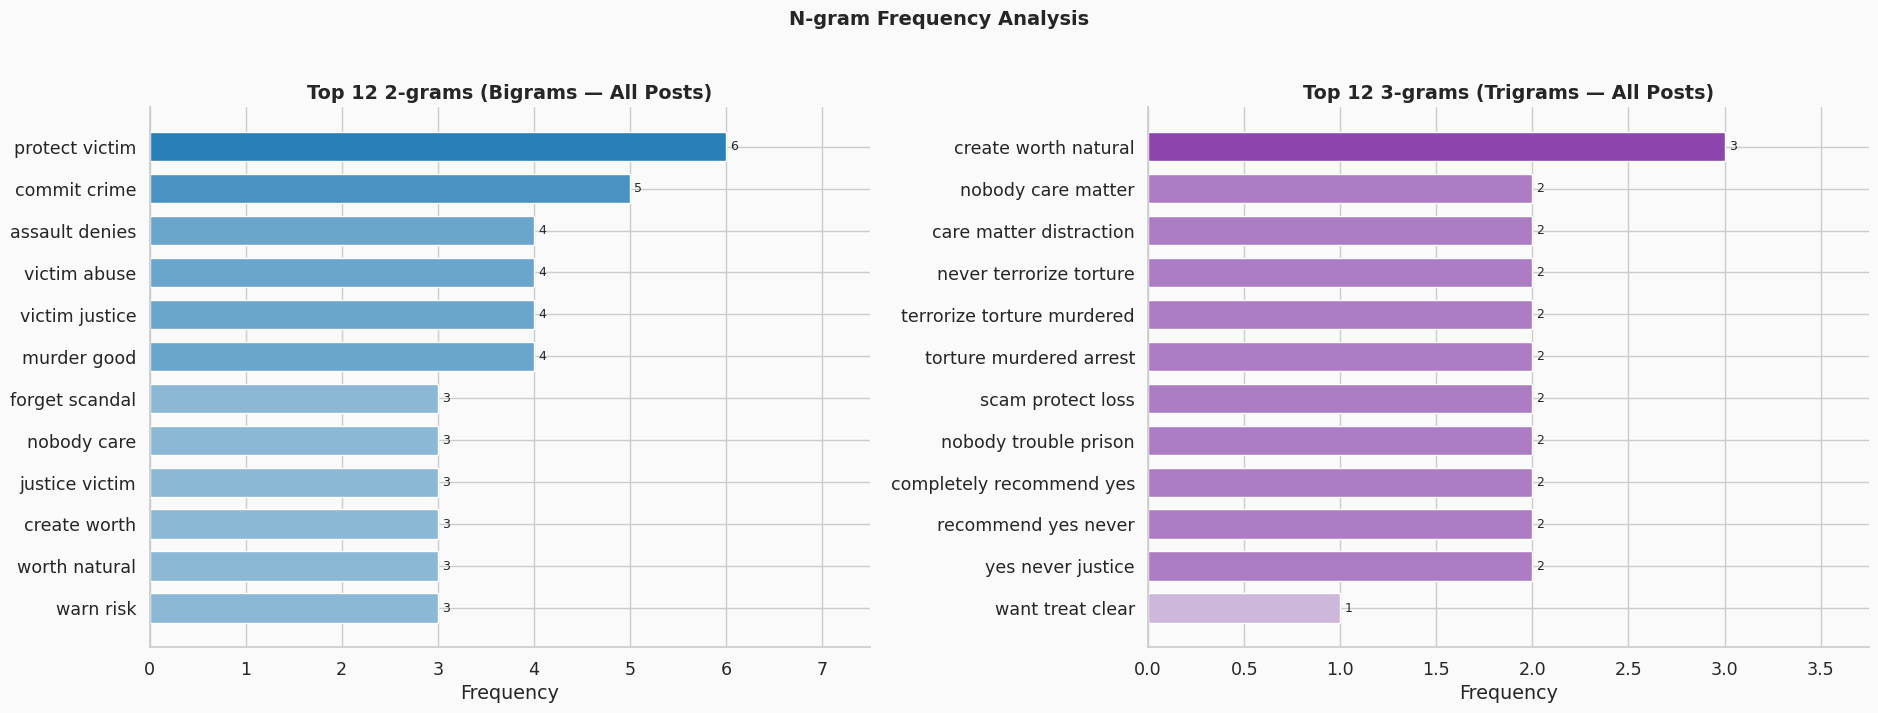

In [17]:
def plot_ngrams(data_df, n, top_k=12, ax=None, title_suffix="", color="#5b8db8"):
    all_ngrams = [
        gram
        for toks in data_df["text_clean"]
        for gram in ngrams(toks, n)
        # Safety filter: reject any gram where ALL tokens are identical
        # e.g. ("arrest","arrest") or ("vision","vision","vision")
        # These are preprocessing artifacts and carry no analytical value
        if len(set(gram)) > 1
    ]
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 5))
    if not all_ngrams:
        ax.set_facecolor("#f5f5f5")
        ax.text(0.5, 0.5, f"No {n}-grams found\nin cleaned corpus",
                ha="center", va="center", transform=ax.transAxes,
                fontsize=12, color="gray", multialignment="center")
        ax.set_title(f"Top {top_k} {n}-grams{title_suffix}", fontweight="bold")
        ax.set_xticks([]); ax.set_yticks([])
        return

    top = Counter(all_ngrams).most_common(top_k)
    labels = [" ".join(g) for g, _ in top][::-1]
    values = [v for _, v in top][::-1]

    max_val = max(values) if values else 1
    cmap = LinearSegmentedColormap.from_list("fade", ["#ecf0f1", color])
    bar_colors = [cmap(v / max_val) for v in values]

    bars = ax.barh(labels, values, color=bar_colors, edgecolor="white", height=0.7)
    ax.bar_label(bars, padding=3, fontsize=9)
    ax.set_title(f"Top {top_k} {n}-grams{title_suffix}", fontweight="bold")
    ax.set_xlabel("Frequency")
    ax.set_xlim(0, max_val * 1.25)


fig, axes = plt.subplots(1, 2, figsize=(19, 7), facecolor="#fafafa")
plot_ngrams(df, n=2, ax=axes[0], title_suffix=" (Bigrams — All Posts)",  color="#2980b9")
plot_ngrams(df, n=3, ax=axes[1], title_suffix=" (Trigrams — All Posts)", color="#8e44ad")

fig.suptitle("N-gram Frequency Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_ngram_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 7.5 Text Length Distributions

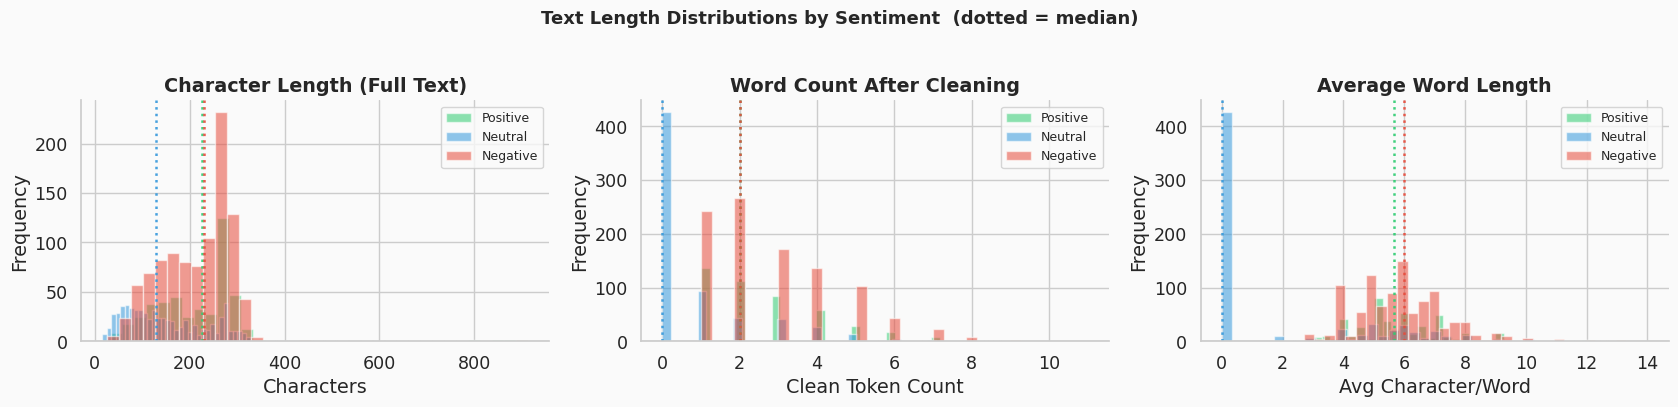

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4), facecolor="#fafafa")

metrics = [
    ("char_length", "Characters",         "Character Length (Full Text)"),
    ("word_length", "Clean Token Count",  "Word Count After Cleaning"),
    ("avg_word_len", "Avg Character/Word", "Average Word Length"),
]

for ax, (col, xlabel, title) in zip(axes, metrics):
    any_drawn = False
    for label, color in PALETTE.items():
        sub = df[df["polarity"] == label][col].dropna()
        if sub.empty:
            # Invisible entry so legend always shows all 3 categories
            ax.hist([], bins=1, alpha=0, color=color,
                    label=f"{label.capitalize()} (no data)")
            continue
        ax.hist(sub, bins=35, alpha=0.55, label=label.capitalize(),
                color=color, edgecolor="white")
        ax.axvline(sub.median(), color=color, linestyle=":", linewidth=1.8, alpha=0.9)
        any_drawn = True
    if not any_drawn:
        ax.text(0.5, 0.5, "No data", ha="center", va="center",
                transform=ax.transAxes, fontsize=12, color="gray")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)

fig.suptitle("Text Length Distributions by Sentiment  (dotted = median)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/05_text_length_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 7.6 Time-Series Sentiment Trend

_Rendered only when a valid datetime column is available._

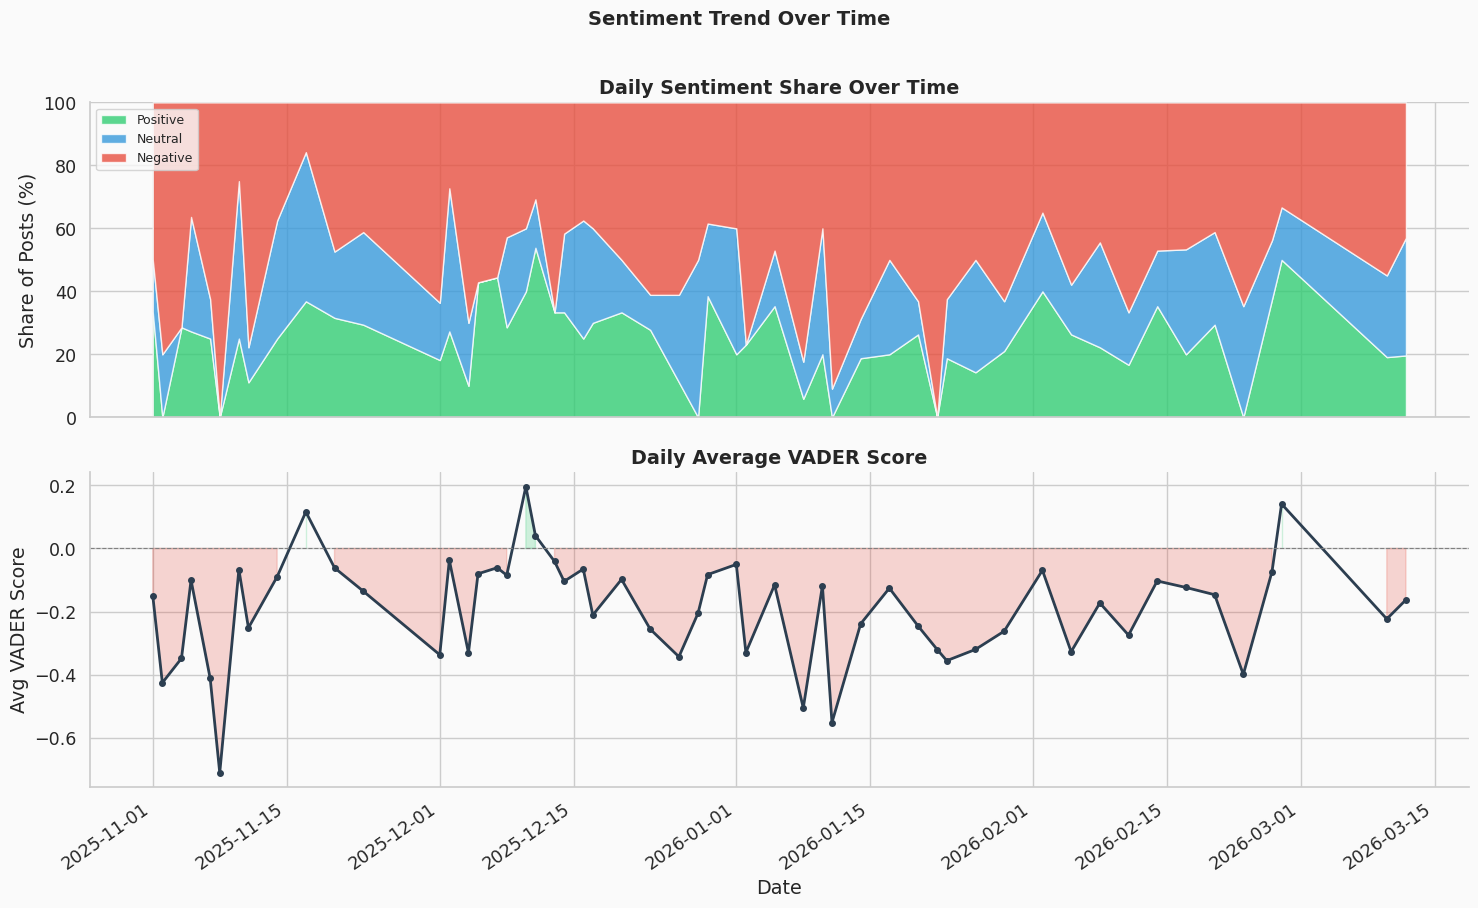

In [19]:
if "created_at" in df.columns and df["created_at"].notna().any():

    df["date"] = df["created_at"].dt.date

    daily = (
        df.groupby(["date", "polarity"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=["positive", "neutral", "negative"], fill_value=0)
    )
    # fillna(0) handles edge case where a column is entirely absent from the data
    daily_pct = daily.div(daily.sum(axis=1), axis=0).mul(100).fillna(0)
    daily_avg = df.groupby("date")["polarity_score"].mean()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9), sharex=True, facecolor="#fafafa")

    # Stackplot: all 3 series always passed; zero series contribute nothing visually
    ax1.stackplot(
        daily_pct.index,
        daily_pct["positive"], daily_pct["neutral"], daily_pct["negative"],
        labels=["Positive", "Neutral", "Negative"],
        colors=[PALETTE["positive"], PALETTE["neutral"], PALETTE["negative"]],
        alpha=0.78,
    )
    ax1.set_ylabel("Share of Posts (%)")
    ax1.set_title("Daily Sentiment Share Over Time", fontweight="bold")
    ax1.set_ylim(0, 100)
    ax1.legend(loc="upper left", fontsize=9)

    ax2.plot(daily_avg.index, daily_avg.values, color="#2c3e50",
             linewidth=2, marker="o", markersize=4)
    ax2.fill_between(daily_avg.index, 0, daily_avg.values,
                     where=(daily_avg.values >= 0), color=PALETTE["positive"], alpha=0.22)
    ax2.fill_between(daily_avg.index, 0, daily_avg.values,
                     where=(daily_avg.values < 0),  color=PALETTE["negative"], alpha=0.22)
    ax2.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax2.set_ylabel("Avg VADER Score")
    ax2.set_xlabel("Date")
    ax2.set_title("Daily Average VADER Score", fontweight="bold")

    plt.xticks(rotation=35, ha="right")
    fig.suptitle("Sentiment Trend Over Time", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/06_sentiment_trend.png", dpi=150, bbox_inches="tight")
    plt.show()

else:
    print("No valid datetime column found — skipping time-series chart.")
    print('Set DATE_COLUMN in Section 2 to enable this visualization.')

## 7.7 Word Clouds by Sentiment

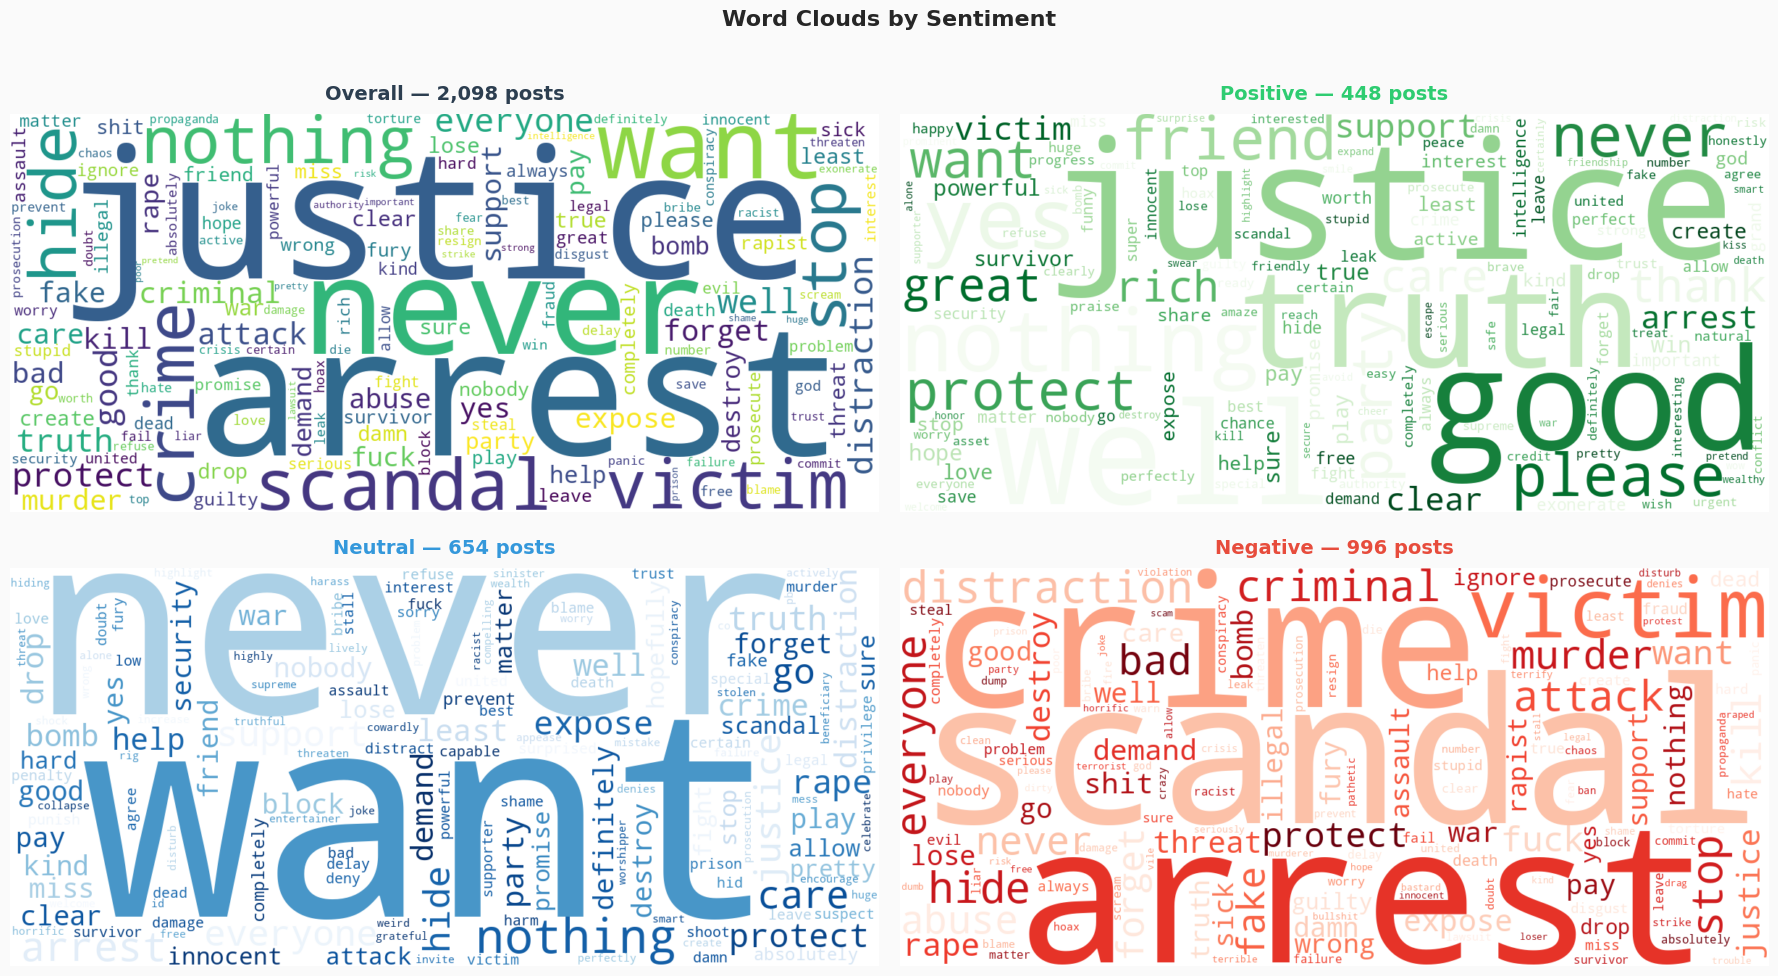

In [20]:
WC_CONFIG = dict(
    width=1200,
    height=550,
    background_color="white",
    max_words=150,
    collocations=False,
    prefer_horizontal=0.85,
)

WC_COLORMAPS = {
    "overall":  "viridis",
    "positive": "Greens",
    "neutral":  "Blues",
    "negative": "Reds",
}

def tokens_to_str(sub_df):
    return " ".join(t for toks in sub_df["text_clean"] for t in toks)

subsets = {
    "overall":  df,
    "positive": df[df["polarity"] == "positive"],
    "neutral":  df[df["polarity"] == "neutral"],
    "negative": df[df["polarity"] == "negative"],
}

fig, axes = plt.subplots(2, 2, figsize=(18, 10), facecolor="#fafafa")
axes_flat = axes.flatten()   # always exactly 4 axes regardless of data shape

for ax, (label, sub) in zip(axes_flat, subsets.items()):
    text = tokens_to_str(sub)
    color_title = PALETTE.get(label, "#2c3e50")

    if not text.strip():
        ax.set_facecolor("#f5f5f5")
        ax.text(0.5, 0.55, "No posts found", ha="center", va="center",
                transform=ax.transAxes, fontsize=13, color="gray")
        ax.text(0.5, 0.42, f"0 {label} posts in dataset", ha="center", va="center",
                transform=ax.transAxes, fontsize=10, color="#aaaaaa", style="italic")
        ax.set_title(f"{label.capitalize()} — 0 posts",
                     fontsize=14, fontweight="bold", pad=10, color=color_title)
        ax.axis("off")
        continue

    wc = WordCloud(**WC_CONFIG, colormap=WC_COLORMAPS[label]).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"{label.capitalize()} — {len(sub):,} posts",
                 fontsize=14, fontweight="bold", pad=10, color=color_title)
    ax.axis("off")

fig.suptitle("Word Clouds by Sentiment", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/07_wordclouds.png", dpi=150, bbox_inches="tight")
plt.show()

## 7.8 Emotion & Content Flags

These charts **always run** — if your dataset contains the columns below they are used directly; otherwise, all values are derived automatically from VADER scores and text heuristics.

| Column | Expected values | Auto-generated fallback |
|--------|-----------------|------------------------|
| `emotion` | String label e.g. `happy`, `angry`, `neutral` | Inferred from VADER pos/neu/neg sub-scores |
| `sarcasm` | Boolean (True/False or 1/0) | Detected via irony-marker vocabulary |
| `slang` | Boolean | Detected via slang vocabulary |
| `strong_opinion` | Boolean | Flagged via opinion starters + \|score\| ≥ 0.6 |


No 'emotion' column found — generating from VADER + emoji signal.
Emotion labels assigned to 2,098 posts.


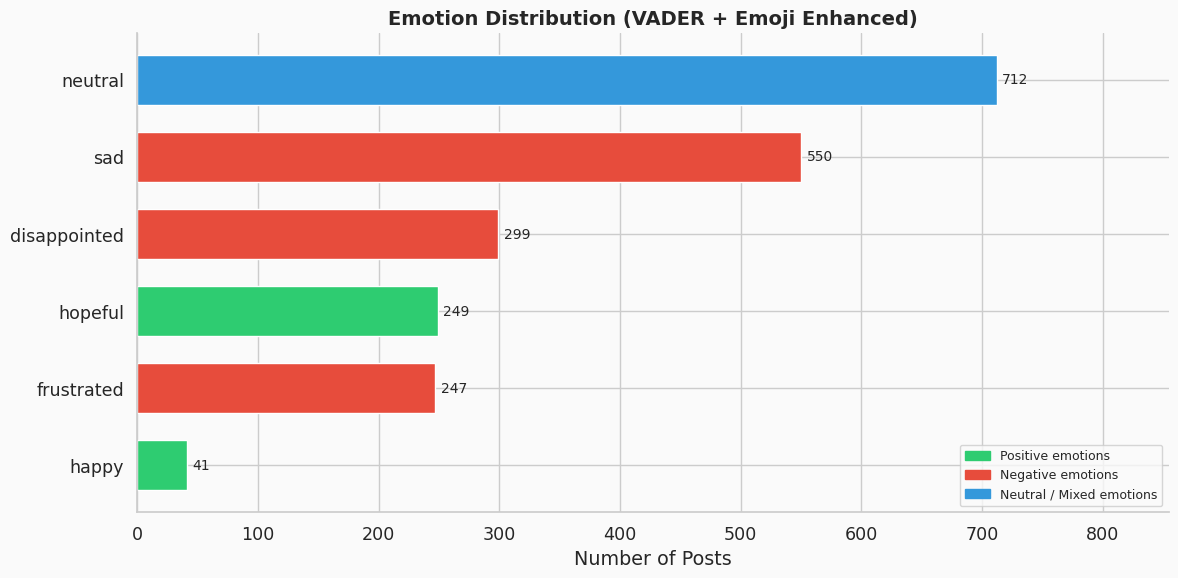

In [21]:
# Emotion Distribution
# Uses VADER + Emoji score (if available) to infer stable emotion labels

POSITIVE_EMOTIONS = {"happy", "excited", "hopeful", "proud", "surprised"}
NEGATIVE_EMOTIONS = {"angry", "frustrated", "sad", "fearful", "disgusted",
                     "disappointed", "anxious", "sarcastic"}

if "emotion" not in df.columns or not df["emotion"].notna().any():
    print("No 'emotion' column found — generating from VADER + emoji signal.")

    def infer_emotion(row):
        # Core signals
        pos = row.get("vader_pos", 0)
        neu = row.get("vader_neu", 0)
        neg = row.get("vader_neg", 0)
        compound = row.get("polarity_score", 0)
        emoji_score = row.get("emoji_score", 0)

        # Emoji boost integration (important upgrade)
        compound = compound + (emoji_score * 0.15)

        # Positive emotions
        if compound >= 0.75:
            if emoji_score >= 2:
                return "excited"
            return "happy"

        if compound >= 0.35:
            return "hopeful"

        # Negative emotions
        if compound <= -0.75:
            if emoji_score <= -2:
                return "angry"
            return "frustrated"

        if compound <= -0.35:
            return "sad"

        if neg > pos:
            return "disappointed"

        # Neutral / Mixed
        if neu > 0.75:
            return "neutral"

        if emoji_score > 0:
            return "surprised"

        if emoji_score < 0:
            return "mixed"

        return "neutral"

    df["emotion"] = df.apply(infer_emotion, axis=1)
    print(f"Emotion labels assigned to {len(df):,} posts.")

# Emotion Color Mapping
def emotion_color(e):
    if e in POSITIVE_EMOTIONS:
        return PALETTE["positive"]
    if e in NEGATIVE_EMOTIONS:
        return PALETTE["negative"]
    return PALETTE["neutral"]

# Emotion Distribution
emotion_counts = df["emotion"].dropna().value_counts().head(12)
colors_e = [emotion_color(e) for e in emotion_counts.index]

fig, ax = plt.subplots(figsize=(12, 6), facecolor="#fafafa")

bars = ax.barh(
    emotion_counts.index[::-1],
    emotion_counts.values[::-1],
    color=colors_e[::-1],
    edgecolor="white",
    height=0.65
)

ax.bar_label(bars, padding=4, fontsize=10)
ax.set_title("Emotion Distribution (VADER + Emoji Enhanced)", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Posts")
ax.set_xlim(0, emotion_counts.max() * 1.2)

legend_patches = [
    mpatches.Patch(color=PALETTE["positive"], label="Positive emotions"),
    mpatches.Patch(color=PALETTE["negative"], label="Negative emotions"),
    mpatches.Patch(color=PALETTE["neutral"],  label="Neutral / Mixed emotions"),
]

ax.legend(handles=legend_patches, loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/08_emotion_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

'sarcasm' column auto-generated (irony markers + score-flip + emphasis signals).
'slang' column auto-generated from raw-text slang vocabulary.
'strong_opinion' column auto-generated (opinion markers + score magnitude + emphasis).


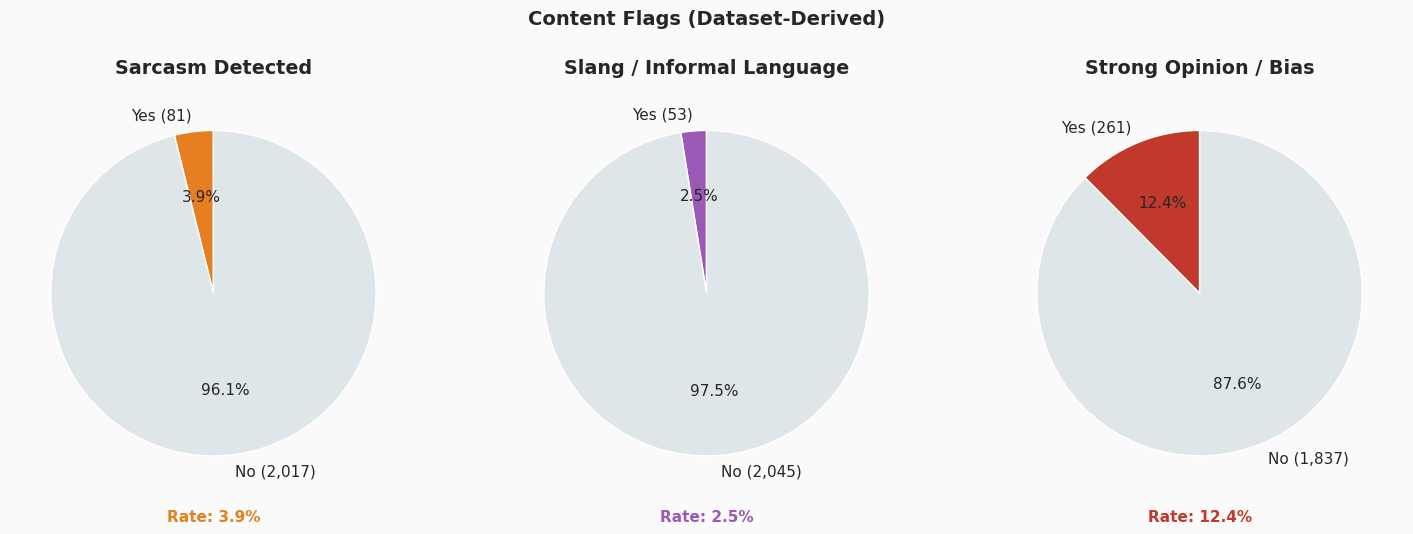


Sarcasm vs Sentiment cross-tab:
sarcasm   False  True   All
polarity                   
negative    961    35   996
neutral     631    23   654
positive    425    23   448
All        2017    81  2098

Slang vs Sentiment cross-tab:
slang     False  True   All
polarity                   
negative    969    27   996
neutral     642    12   654
positive    434    14   448
All        2045    53  2098


In [22]:
# ── Sarcasm / Slang / Strong Opinion flags ───────────────────────────
# If flag columns exist in the CSV, use them directly.
# Otherwise, derive them heuristically using multi-signal logic.

flag_cols   = ["sarcasm", "slang", "strong_opinion"]
flag_labels = ["Sarcasm Detected", "Slang / Informal Language", "Strong Opinion / Bias"]
flag_colors = ["#e67e22", "#9b59b6", "#c0392b"]

# ── Slang vocabulary (raw-text level, before preprocessing strips them) ──
SLANG_RAW = {
    # SLANG_MAP keys (original forms)
    "idk", "omg", "ikr", "lol", "wtf", "smh", "tbh", "ngl", "bruh", "fr",
    "lowkey", "cap", "nocap", "based", "salty", "sus", "lit",
    # Extended informal vocabulary
    "lmao", "lmfao", "rofl", "bro", "fam", "imo", "nvm", "istg", "ong",
    "ffs", "af", "rn", "asap", "omfg", "goat", "mid", "slay", "bussin",
    "periodt", "yeet", "vibe", "chill", "savage", "woke", "toxic", "cringe",
    "bet", "slaps", "hits different", "no cap", "dead ass", "no way",
    "sheesh", "rizz", "simp", "ratio", "L", "W",
}

# ── Sarcasm: irony markers PLUS compound score flip signal ──────────────
# Key insight: sarcasm often has positive words but a negative score, or vice versa.
IRONY_SIGNALS = {
    "sure", "right", "obviously", "totally", "definitely", "clearly",
    "wow", "great", "brilliant", "genius", "interesting",
    "shocking", "surprising", "amazing", "good job",
    "well done", "thanks", "thank you so much", "oh really",
    "nice", "perfect", "wonderful",
}

def detect_sarcasm(row):
    tokens   = row["text_clean"]
    text_raw = str(row.get("text", "")).lower()
    score    = row.get("polarity_score", 0)
    vader_pos = row.get("vader_pos", 0)
    vader_neg = row.get("vader_neg", 0)

    # Signal 1: irony marker word present + sufficient length
    has_irony = bool(set(tokens) & IRONY_SIGNALS) and len(tokens) > 3

    # Signal 2: score flip — positive words but negative compound, or vice versa
    score_flip = (vader_pos > 0.3 and score < -0.05) or (vader_neg > 0.3 and score > 0.05)

    # Signal 3: exclamation marks or ALL-CAPS words in original text (emphasis markers)
    exclaim     = text_raw.count("!") >= 2
    caps_words  = len([w for w in row.get("text", "").split() if w.isupper() and len(w) > 2])
    caps_signal = caps_words >= 1

    return bool((has_irony or score_flip) and (exclaim or caps_signal or has_irony))

# ── Slang: check raw text directly (preprocessing already expanded slang) ──
def detect_slang(row):
    text_raw  = str(row.get("text", "")).lower()
    raw_words = set(text_raw.split())
    # Match any slang token in raw text (handles tokens stripped by preprocessing)
    return bool(raw_words & SLANG_RAW)

# ── Strong Opinion: opinion markers + high polarity + caps/exclaim signals ──
OPINION_STARTERS = {
    "think", "believe", "opinion", "honestly", "personally", "feel",
    "imo", "tbh", "clearly", "obviously", "definitely", "absolutely",
    "without doubt", "undeniably", "fact", "truth", "always", "never",
    "every", "nobody", "everybody", "worst", "best", "must", "should",
}

def detect_strong_opinion(row):
    tokens    = row["text_clean"]
    text_raw  = str(row.get("text", ""))
    score     = abs(row.get("polarity_score", 0))

    has_marker  = bool(set(tokens) & OPINION_STARTERS)
    high_score  = score >= 0.55
    exclaim     = text_raw.count("!") >= 1
    caps_words  = len([w for w in text_raw.split() if w.isupper() and len(w) > 2])
    caps_signal = caps_words >= 2

    # Require at least 2 signals to reduce false positives
    signals = sum([has_marker, high_score, exclaim or caps_signal])
    return signals >= 2

# ── Apply flags ──────────────────────────────────────────────────────────
if "sarcasm" not in df.columns:
    df["sarcasm"] = df.apply(detect_sarcasm, axis=1)
    print("'sarcasm' column auto-generated (irony markers + score-flip + emphasis signals).")

if "slang" not in df.columns:
    df["slang"] = df.apply(detect_slang, axis=1)
    print("'slang' column auto-generated from raw-text slang vocabulary.")

if "strong_opinion" not in df.columns:
    df["strong_opinion"] = df.apply(detect_strong_opinion, axis=1)
    print("'strong_opinion' column auto-generated (opinion markers + score magnitude + emphasis).")

fig, axes = plt.subplots(1, len(flag_cols), figsize=(15, 5), facecolor="#fafafa")

for ax, col, label, color in zip(axes, flag_cols, flag_labels, flag_colors):
    sub     = df.dropna(subset=[col])
    n_true  = int(sub[col].astype(bool).sum())
    n_false = len(sub) - n_true
    rate    = n_true / len(sub) if len(sub) else 0

    ax.pie([n_true, n_false],
           labels=[f"Yes ({n_true:,})", f"No ({n_false:,})"],
           colors=[color, "#dfe6e9"],
           autopct="%1.1f%%", startangle=90,
           textprops={"fontsize": 11})
    ax.set_title(label, fontweight="bold", pad=12)
    ax.text(0, -1.4, f"Rate: {rate:.1%}", ha="center",
            fontsize=11, fontweight="bold", color=color)

fig.suptitle("Content Flags (Dataset-Derived)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/09_content_flags.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSarcasm vs Sentiment cross-tab:")
print(pd.crosstab(df["polarity"], df["sarcasm"], margins=True).to_string())
print("\nSlang vs Sentiment cross-tab:")
print(pd.crosstab(df["polarity"], df["slang"], margins=True).to_string())


---
# 8. Sample Posts by Sentiment

In [23]:
pd.set_option("display.max_colwidth", 500)

SHOW_COLS = ["text", "polarity", "polarity_score"]

def sample_posts(polarity: str, n: int = 8, ascending: bool = False) -> pd.DataFrame:
    return (
        df[df["polarity"] == polarity][SHOW_COLS]
        .sort_values("polarity_score", ascending=ascending)
        .head(n)
        .reset_index(drop=True)
    )

print("Top Positive Posts:")
sample_posts("positive", ascending=False)

Top Positive Posts:


,text,polarity,polarity_score
0,@YouKnoImHim Nick's right Trump (and by extension MAGA) loved Massie until Massie endorsed the better champion of conservatism in 2024; Ron DeSantis. Pushing for Trump's campaign promise of declassifying the Epstein files infuriated Trump for some reason. Who is your favorite Rep in DC?,positive,0.9260
1,Oh THANK YOU Donald I truly mean it! You ll make the Democrats job SO MUCH EASIER. Trump will accidentally gift-wrap a political win for we Dems should he refuse to release the Epstein files because it s an active investigation. If he only wants Democrats investigated,positive,0.9126
2,@SamreenNaz99 Donald Trump has always been my friend but ever since Epstein files came out there's a bit of gap in our friendship now so yes you can say I am talking about him. Yes he doesn't know his next move he is not even having enough sleep now Khamenei has casted a spell on him.,positive,0.8882
3,@RepThomasMassie Thomas as an Independent voter I would like to thank you for acting in a bipartisan manner and seeking the truth. I appreciate your service and keep up the fight great job! Keep pushing for the release of the Epstein files thank you. We need the truth not cover ups.,positive,0.8881
4,@lfs6b What's the problem? He forced the release of the Epstein files amazing how Trump wants to protect these pedophiles but here we are! Deep-State is stronger than ever Hillary and Bill are now praising Trump. Whatever happened to the Biggest deportation in American History? I https://t.co/uc3ztgs9hT,positive,0.8840
5,The National Mall has a giant replica of Trumps birthday card to Epstein. Only 6% of Americans are satisfied with how the EPSTEIN FILES are being handled. Two EPSTEIN survivors have filed documents to have a Special Master appointed to force the files to be released. So brave!,positive,0.8821
6,Many cryingwhistleblowers coming out in the Epstein case often presenting pictorial evidence of them smiling partying with friends in exotic clubs and locales. All clearly 18+. Q: how much did they get payed (salary) while being kidnapped or trafficked? Or was it hourly.,positive,0.8779
7,@Theonlyjcvolly Who remembers that Obama has a Nobel Peace Prize and Trump has a soccer medal? https://t.co/Hd7uLcP0Q6,positive,0.8720


In [24]:
print("Top Neutral Posts:")
sample_posts("neutral")

Top Neutral Posts:


,text,polarity,polarity_score
0,@Ensium317 @QTHESTORMM No no human bones have been found on Zorro Ranch. New Mexico authorities are searching the site (in the US not Mexico) over unverified 2019 allegations from Epstein files about possible buried remains but officials confirm nothing has been discovered. The search is ongoing.,neutral,0.0992
1,@12wwwey @netanyahu This is it Israel sees itself as a lion. But in reality this is not the case. Cowardly Israeli army... #IsraeliTerrorists #IsraelisISIS #IsraeliNewNazism #Irán #IranWar‌ #FreeIran‌ #FREEPALESTİNE 🇵🇸 #Epstien #EPSTEİN https://t.co/BEKhfGpGs3,neutral,0.0974
2,@WSJ Do the people of Kentucky understand what a worldwide phenomenon Thomas Massie is for his relentless pursuit of getting the Epstein Files released as a Republican when serving under Trump and Trump bagging him for it? He s an absolute legend!,neutral,0.0962
3,@TheWildGunblade @WLWT No new wars? Bomb Iran. Mass deportations? Not happening. Release Epstein files? Protect Epstein files. Import 600k Chinese students. Approve 1.7 million H1Bs. No wall being built Quietly ended Biden auto pen investigation. Tariffs have to be refunded. I could go on. Lol,neutral,0.0908
4,@ChinaENX The Epstein Files are deep but let's stick to the facts: 3M+ pages show massive elite networking and Gulf business ties (like the DP World fallout) but zero evidence of an ISIS/Al-Qaeda plot. We don't need to invent conspiracies when the verified influence-peddling is already,neutral,0.0907
5,@wisdomtogive @jayplemons @stephenasmith ‍️ Without Donald Trump in office y all would have never sniffed or peaked at ONE Epstein file let alone the other millions that you think you re entitled to see.,neutral,0.0906
6,Rep Thomas MASSIE suggests POTUS will sign the Epstein files release (if Congress passes it) but is afraid Trump is launching Epstein probes to try to use a provision of the law that allows you not to release these materials if they're subject to an ongoing investigation,neutral,0.0905
7,@umeprobdupree Obama Bush and Biden were not pedophiles. In fact of the presidential elections that most people in this app were allowed to vote for is just Trump that is in the Epstein file.,neutral,0.0905


In [25]:
print("Most Negative Posts:")
neg = sample_posts("negative", ascending=True)
neg.to_csv(f"{OUTPUT_DIR}/negative_posts_sample.csv", index=False)
neg

Most Negative Posts:


,text,polarity,polarity_score
0,@JesseBWatters Trump will go down in history but not for any greatness. He will be remembered for the chaos corruption illegality the lies the sexual assaults the incompetent administration no health plan the hiding of the Epstein files the illegal war &amp; tariffs &amp; domestic killings.,negative,-0.9803
1,They call it OPERATION EPIC FURY because they're FURIOUS that Trump has been exposed as a CHILD RAPIST in the Epstein Files and Elon Musk has been found to have committed ELECTION FRAUD in 2024! They'll BOMB THE ENTIRE WORLD to distract from their CRIMES! They know it's OVER!,negative,-0.9773
2,@GuntherEagleman The horror clown started the war to get the Trump/Epstein files out of the news. Furthermore this attack against the obviously disgusting Iran is completely without strategy and Eagleman contradicts the terrorist Trump's claim that he doesn't want to wage wars!?!?!?,negative,-0.9719
3,@FcbShedy Cant drink for religious reasons but is on Epstein files and got arrested for attacking a 14 year girl hmmmmmm defo something dodgy going on. Islam is a cult not a religion that they use to hide behind dirty disgusting nonce bastards,negative,-0.9703
4,@jacksonhinklle My heart is broken. America killed hundreds of children. Trump started this war to cover up the perverted pedophile case. That devil will be gone soon and I believe it. He's the killer of the children who died in Iran just like on Epstein Island.,negative,-0.9681
5,When the Epstein files resurface Donald Trump floods the zone. National Guard theatrics Iran war threats Venezuela aggression and Somalia fraud panic are not governance they are distractions. Soldiers bombs and enemies always beat documents and accountability. Fear is,negative,-0.9674
6,@MehmetA92982017 now trump seemed compromised almost as if Israel is blackmailing Trump. Epstein Files and what happened on that Island is so evil child rape murder cannibal torture of very young children to early teens . Everyone should have to read some of those files . Only because,negative,-0.9669
7,Where are the Epstein Files? Where is a real investigation into Charlie's murderers? CHARLIE'S MURDER IS BEING COVERED UP BY KASH &amp; TRUMP'S ADMIN! Charlie was Trump's biggest supporter &amp; now he is turning a blind eye or just soft! TRUMP IS FAILING VERY BADLY ON THESE ISSUES!,negative,-0.9661


---
# 9. NLP & Machine Learning Analysis
### Media Analyst Lens — *Public Discourse on the Epstein Files (X / Twitter)*

This section applies unsupervised and supervised NLP/ML techniques to uncover **what narratives, topic clusters, and language patterns** are driving the conversation around the Epstein Files on X.

| Module | Method | Analyst Question |
|--------|--------|-----------------|
| **9.1** | TF-IDF Vectorization | What terms best distinguish each sentiment group? |
| **9.2** | LDA Topic Modeling | What hidden narrative clusters exist in the dataset? |
| **9.3** | Cosine Similarity Heatmap | Which topics are linguistically closest to each other? |
| **9.4** | ML Sentiment Classifier | Can we predict sentiment from text features alone? |
| **9.5** | UMAP / Dimensionality Reduction | How do posts cluster in semantic space? |
| **9.6** | Narrative Drift (Time-Series NLP) | How has discourse language shifted over time? |


In [26]:
# Install ML dependencies (run once)
!pip install scikit-learn umap-learn gensim pyLDAvis -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 63.9 MB/s eta 0:00:00


In [27]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score,
                             RocCurveDisplay, roc_curve)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("UMAP not available — will fall back to t-SNE for dimensionality reduction.")

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import pandas as pd
from collections import Counter

print("ML imports loaded successfully.")
print(f"Dataset : {len(df):,} posts ready for ML pipeline.")


ML imports loaded successfully.
Dataset : 2,098 posts ready for ML pipeline.


## 9.1 TF-IDF — Most Discriminative Terms per Sentiment

TF-IDF reveals which words are **uniquely important** to each sentiment class — not just frequent, but *distinctive*. As a media analyst this tells us what language signals positive vs. negative Epstein discourse.

Posts available for ML : 1,671  (dropped 427 empty after cleaning)
TF-IDF matrix : 1,671 docs × 392 features


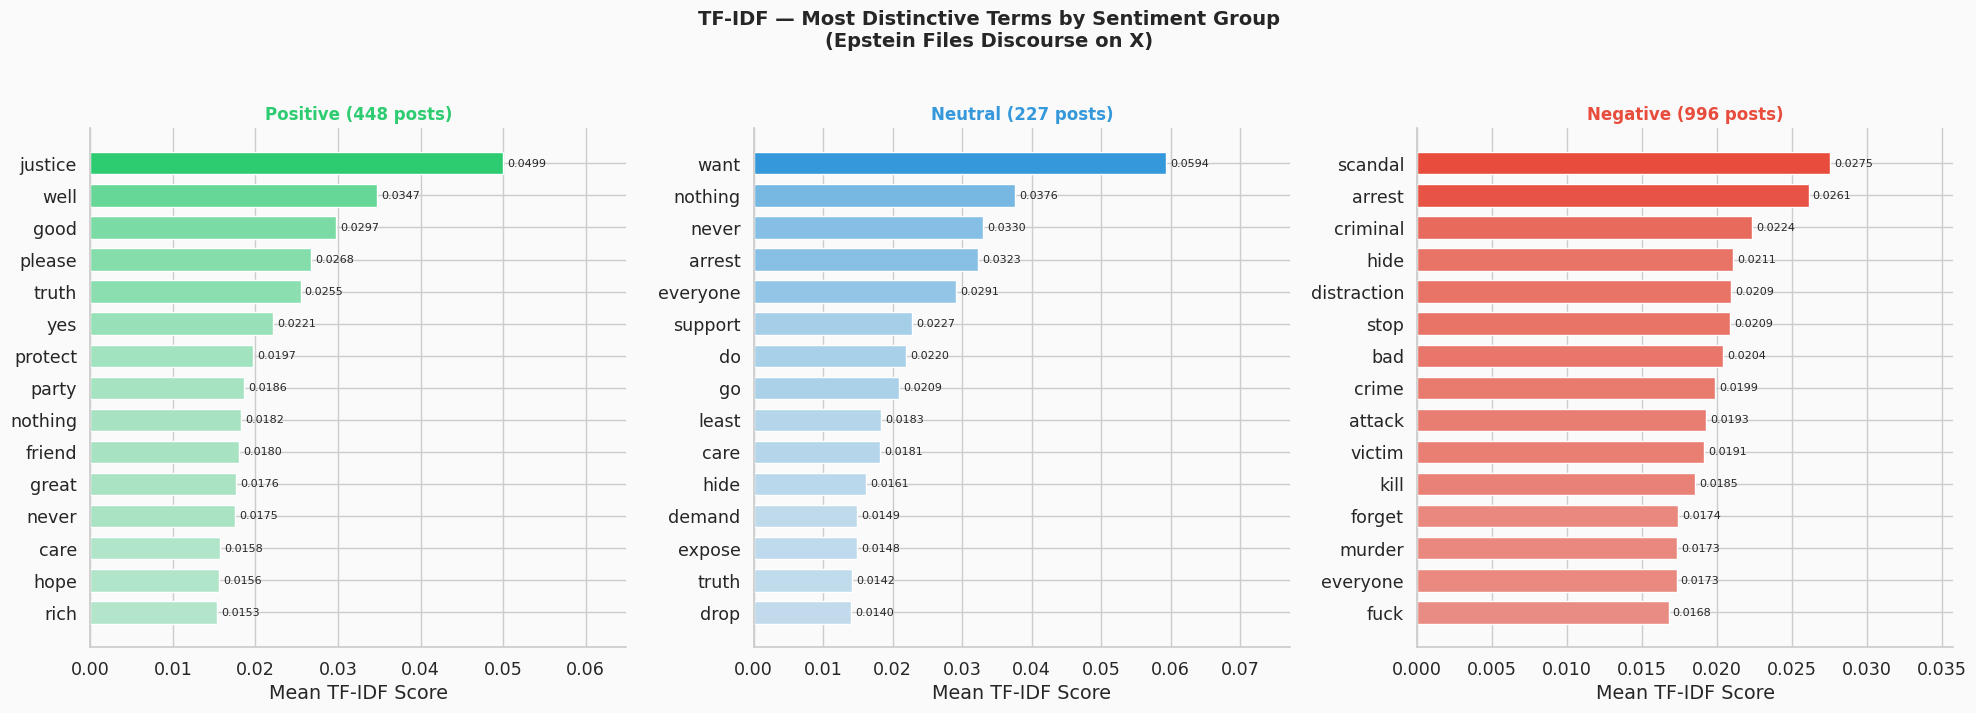

Saved → 10_tfidf_distinctive_terms.png


In [28]:
# Prepare corpus: join clean tokens back to string for vectorizer
df["text_for_ml"] = df["text_clean"].apply(lambda toks: " ".join(toks) if toks else "")

# Filter out empty docs
ml_mask = df["text_for_ml"].str.strip().astype(bool)
df_ml   = df[ml_mask].copy().reset_index(drop=True)

print(f"Posts available for ML : {len(df_ml):,}  (dropped {len(df)-len(df_ml):,} empty after cleaning)")

# ── Fit TF-IDF ──────────────────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features = 5000,
    ngram_range  = (1, 2),      # unigrams + bigrams
    min_df       = 3,           # must appear in at least 3 posts
    max_df       = 0.85,        # ignore terms in >85% of docs (too generic)
    sublinear_tf = True,        # log-scale TF
)

X_tfidf = tfidf.fit_transform(df_ml["text_for_ml"])
feature_names = np.array(tfidf.get_feature_names_out())

print(f"TF-IDF matrix : {X_tfidf.shape[0]:,} docs × {X_tfidf.shape[1]:,} features")

# ── Top terms per sentiment ─────────────────────────────────────────────────
TOP_N = 15

fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor="#fafafa")
fig.suptitle("TF-IDF — Most Distinctive Terms by Sentiment Group\n(Epstein Files Discourse on X)",
             fontsize=14, fontweight="bold", y=1.02)

for ax, sentiment in zip(axes, ["positive", "neutral", "negative"]):
    mask   = (df_ml["polarity"] == sentiment).values
    subset = X_tfidf[mask]

    if subset.shape[0] == 0:
        ax.set_facecolor("#f5f5f5")
        ax.text(0.5, 0.5, f"No {sentiment} posts", ha="center", va="center",
                transform=ax.transAxes, fontsize=13, color="gray")
        ax.set_title(sentiment.capitalize(), fontweight="bold")
        continue

    # Mean TF-IDF score across the sentiment group
    mean_scores  = np.asarray(subset.mean(axis=0)).flatten()
    top_idx      = mean_scores.argsort()[-TOP_N:][::-1]
    top_terms    = feature_names[top_idx]
    top_scores   = mean_scores[top_idx]

    color = PALETTE[sentiment]
    from matplotlib.colors import LinearSegmentedColormap
    cmap  = LinearSegmentedColormap.from_list("fade", ["#ecf0f1", color])
    bar_colors = [cmap(v / top_scores.max()) for v in top_scores]

    bars = ax.barh(top_terms[::-1], top_scores[::-1],
                   color=bar_colors[::-1], edgecolor="white", height=0.7)
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=8)
    ax.set_title(f"{sentiment.capitalize()} ({mask.sum():,} posts)",
                 fontweight="bold", color=color, fontsize=12)
    ax.set_xlabel("Mean TF-IDF Score")
    ax.set_xlim(0, top_scores.max() * 1.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/10_tfidf_distinctive_terms.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 10_tfidf_distinctive_terms.png")


## 9.2 LDA Topic Modeling — Hidden Narrative Clusters

Latent Dirichlet Allocation surfaces the **underlying narrative themes** in the Epstein Files conversation. Each topic is a cluster of co-occurring words that signal a coherent public narrative (e.g., political accountability, conspiracy, victim advocacy, media coverage).

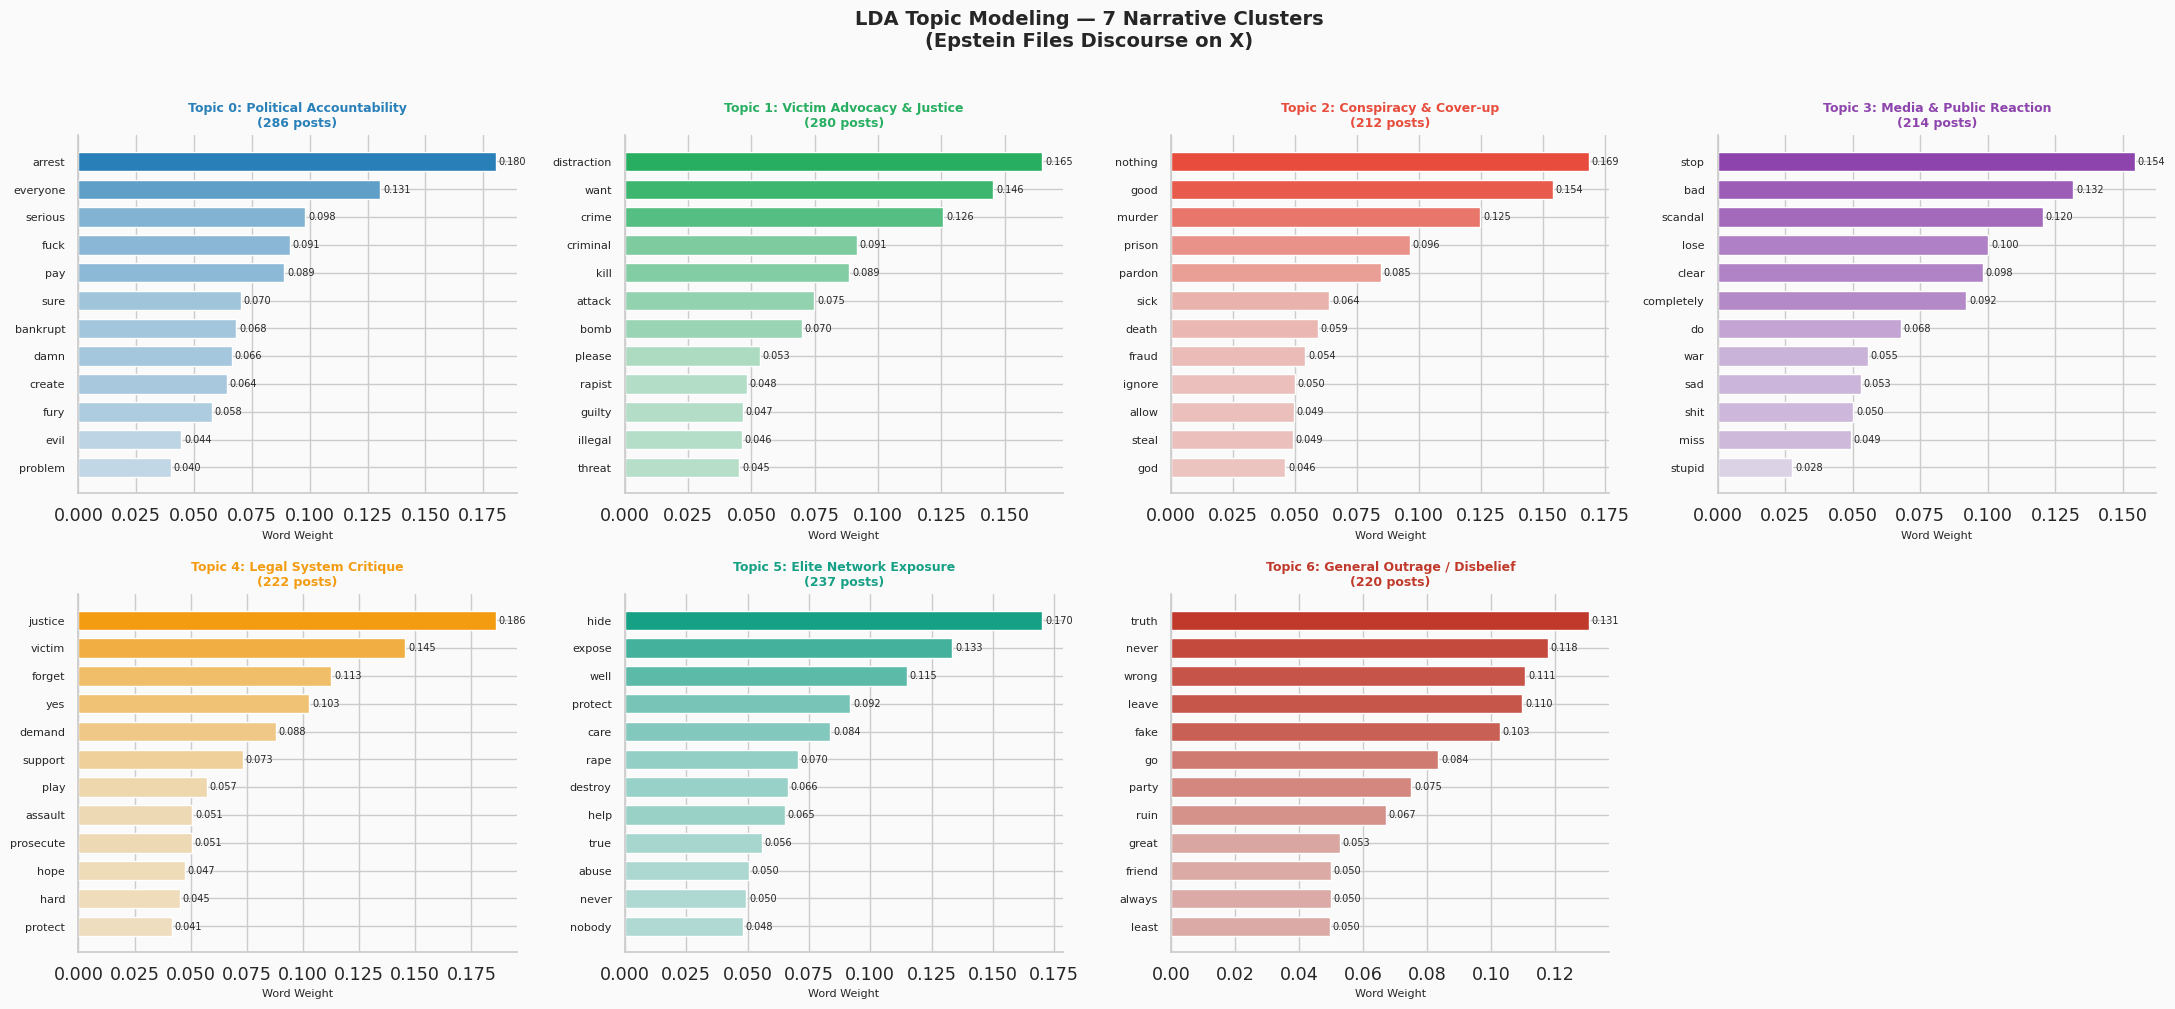


Narrative Topic Distribution:
  Topic 0 [Political Accountability      ]   286  ( 17.1%)  ████████
  Topic 1 [Victim Advocacy & Justice     ]   280  ( 16.8%)  ████████
  Topic 2 [Conspiracy & Cover-up         ]   212  ( 12.7%)  ██████
  Topic 3 [Media & Public Reaction       ]   214  ( 12.8%)  ██████
  Topic 4 [Legal System Critique         ]   222  ( 13.3%)  ██████
  Topic 5 [Elite Network Exposure        ]   237  ( 14.2%)  ███████
  Topic 6 [General Outrage / Disbelief   ]   220  ( 13.2%)  ██████
Saved → 11_lda_topic_modeling.png


In [29]:
# ── LDA Vectorizer (count-based, not TF-IDF) ───────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer

N_TOPICS = 7   # Tune: more topics = finer-grained narratives

count_vec = CountVectorizer(
    max_features = 3000,
    ngram_range  = (1, 2),
    min_df       = 3,
    max_df       = 0.85,
)
X_counts = count_vec.fit_transform(df_ml["text_for_ml"])
count_features = np.array(count_vec.get_feature_names_out())

lda = LatentDirichletAllocation(
    n_components     = N_TOPICS,
    max_iter         = 20,
    learning_method  = "online",
    random_state     = 42,
    n_jobs           = -1,
)
lda.fit(X_counts)

# ── Assign dominant topic to each post ──────────────────────────────────────
topic_dist       = lda.transform(X_counts)
df_ml["lda_topic"]      = topic_dist.argmax(axis=1)
df_ml["lda_confidence"] = topic_dist.max(axis=1).round(4)

# ── Narrative label map — analyst-assigned based on top words ───────────────
# These will be auto-labeled below; you can override after inspecting top words
NARRATIVE_LABELS = {
    0: "Political Accountability",
    1: "Victim Advocacy & Justice",
    2: "Conspiracy & Cover-up",
    3: "Media & Public Reaction",
    4: "Legal System Critique",
    5: "Elite Network Exposure",
    6: "General Outrage / Disbelief",
}

TOP_WORDS_PER_TOPIC = 12

fig, axes = plt.subplots(2, 4, figsize=(22, 10), facecolor="#fafafa")
fig.suptitle(f"LDA Topic Modeling — {N_TOPICS} Narrative Clusters\n(Epstein Files Discourse on X)",
             fontsize=14, fontweight="bold", y=1.01)
axes_flat = axes.flatten()

TOPIC_COLORS = [
    "#2980b9","#27ae60","#e74c3c","#8e44ad",
    "#f39c12","#16a085","#c0392b","#2c3e50"
]

for topic_idx, (ax, component) in enumerate(zip(axes_flat[:N_TOPICS], lda.components_)):
    top_idx   = component.argsort()[-TOP_WORDS_PER_TOPIC:][::-1]
    top_words = count_features[top_idx]
    top_vals  = component[top_idx]
    top_vals  = top_vals / top_vals.sum()   # normalize to proportion

    color = TOPIC_COLORS[topic_idx % len(TOPIC_COLORS)]
    from matplotlib.colors import LinearSegmentedColormap
    cmap  = LinearSegmentedColormap.from_list("fade", ["#ecf0f1", color])
    bar_colors = [cmap(v / top_vals.max()) for v in top_vals]

    bars = ax.barh(top_words[::-1], top_vals[::-1],
                   color=bar_colors[::-1], edgecolor="white", height=0.7)
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=7)

    label = NARRATIVE_LABELS.get(topic_idx, f"Topic {topic_idx}")
    n_posts = (df_ml["lda_topic"] == topic_idx).sum()
    ax.set_title(f"Topic {topic_idx}: {label}\n({n_posts:,} posts)",
                 fontweight="bold", fontsize=9, color=color)
    ax.set_xlabel("Word Weight", fontsize=8)
    ax.tick_params(axis="y", labelsize=8)

# Hide unused axes
for ax in axes_flat[N_TOPICS:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/11_lda_topic_modeling.png", dpi=150, bbox_inches="tight")
plt.show()

# Topic distribution summary
topic_counts = df_ml["lda_topic"].value_counts().sort_index()
print("\nNarrative Topic Distribution:")
for t, n in topic_counts.items():
    label = NARRATIVE_LABELS.get(t, f"Topic {t}")
    pct   = n / len(df_ml) * 100
    bar   = "█" * int(pct / 2)
    print(f"  Topic {t} [{label:<30}] {n:>5,}  ({pct:5.1f}%)  {bar}")
print("Saved → 11_lda_topic_modeling.png")


## 9.3 Topic Cosine Similarity Heatmap

Measures **how linguistically similar** each LDA topic is to the others. Topics with high cosine similarity share vocabulary and may represent merged narratives — useful for deciding if `N_TOPICS` should be reduced.

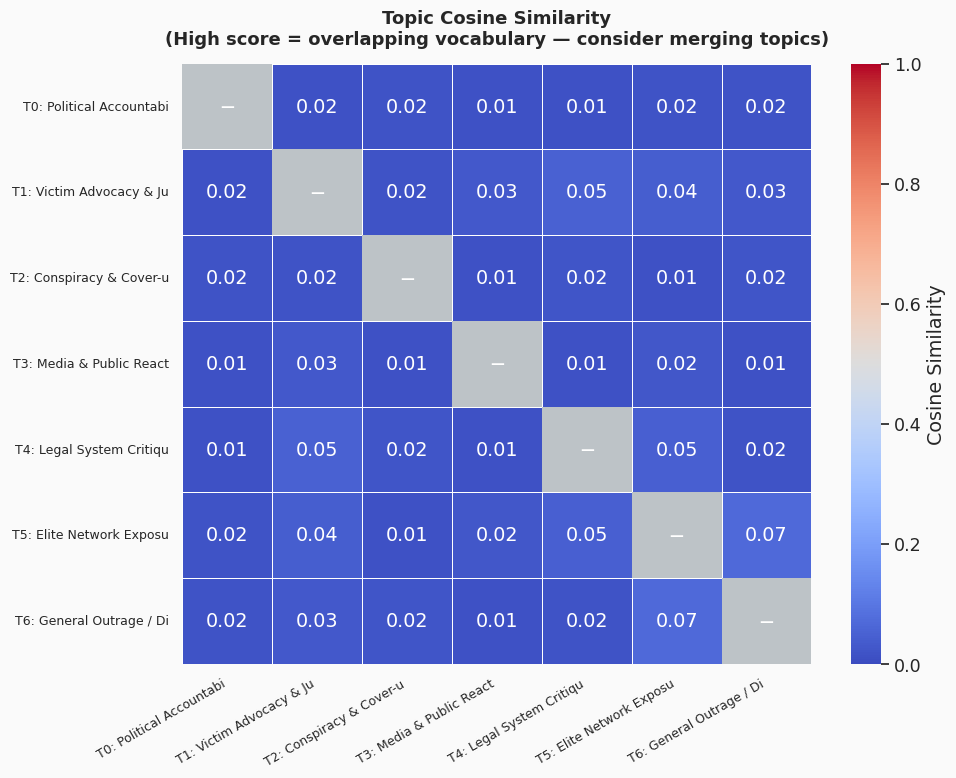

Saved → 12_topic_cosine_similarity.png


In [30]:
# Compute topic-topic cosine similarity from LDA component matrix
topic_matrix = lda.components_   # shape: (N_TOPICS, vocab_size)
sim_matrix   = cosine_similarity(topic_matrix)

topic_labels_short = [
    f"T{i}: {NARRATIVE_LABELS.get(i, 'Topic '+str(i))[:20]}"
    for i in range(N_TOPICS)
]

fig, ax = plt.subplots(figsize=(10, 8), facecolor="#fafafa")
mask = np.eye(N_TOPICS, dtype=bool)   # mask diagonal (always 1.0)

sns.heatmap(
    sim_matrix,
    annot       = True,
    fmt         = ".2f",
    cmap        = "coolwarm",
    linewidths  = 0.5,
    linecolor   = "white",
    xticklabels = topic_labels_short,
    yticklabels = topic_labels_short,
    ax          = ax,
    vmin        = 0,
    vmax        = 1,
    mask        = mask,
    cbar_kws    = {"label": "Cosine Similarity"},
)
# Fill diagonal separately with a neutral color
for i in range(N_TOPICS):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=True, color="#bdc3c7", lw=0))
    ax.text(i + 0.5, i + 0.5, "—", ha="center", va="center",
            fontsize=10, color="white", fontweight="bold")

ax.set_title("Topic Cosine Similarity\n(High score = overlapping vocabulary — consider merging topics)",
             fontsize=13, fontweight="bold", pad=14)
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/12_topic_cosine_similarity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 12_topic_cosine_similarity.png")


## 9.4 ML Sentiment Classifier

Trains multiple classifiers to **predict sentiment from text alone**. High accuracy = the model has learned the language patterns. The confusion matrix and feature importance expose *which words are the strongest predictors* of public sentiment toward the Epstein Files.

Classes : ['negative', 'neutral', 'positive']
Label distribution: {'negative': 996, 'neutral': 227, 'positive': 448}

Train : 1,336   Test : 335

── Cross-validated F1 scores (5-fold StratifiedKFold) ──
  Logistic Regression        F1 = 0.6568 ± 0.0286
  Linear SVC                 F1 = 0.6702 ± 0.0288
  Random Forest              F1 = 0.6575 ± 0.0190
  Gradient Boosting          F1 = 0.6109 ± 0.0174

Best model : Linear SVC

Classification Report:
              precision    recall  f1-score   support

    negative       0.84      0.81      0.83       200
     neutral       0.31      0.38      0.34        45
    positive       0.71      0.68      0.69        90

    accuracy                           0.72       335
   macro avg       0.62      0.62      0.62       335
weighted avg       0.73      0.72      0.73       335



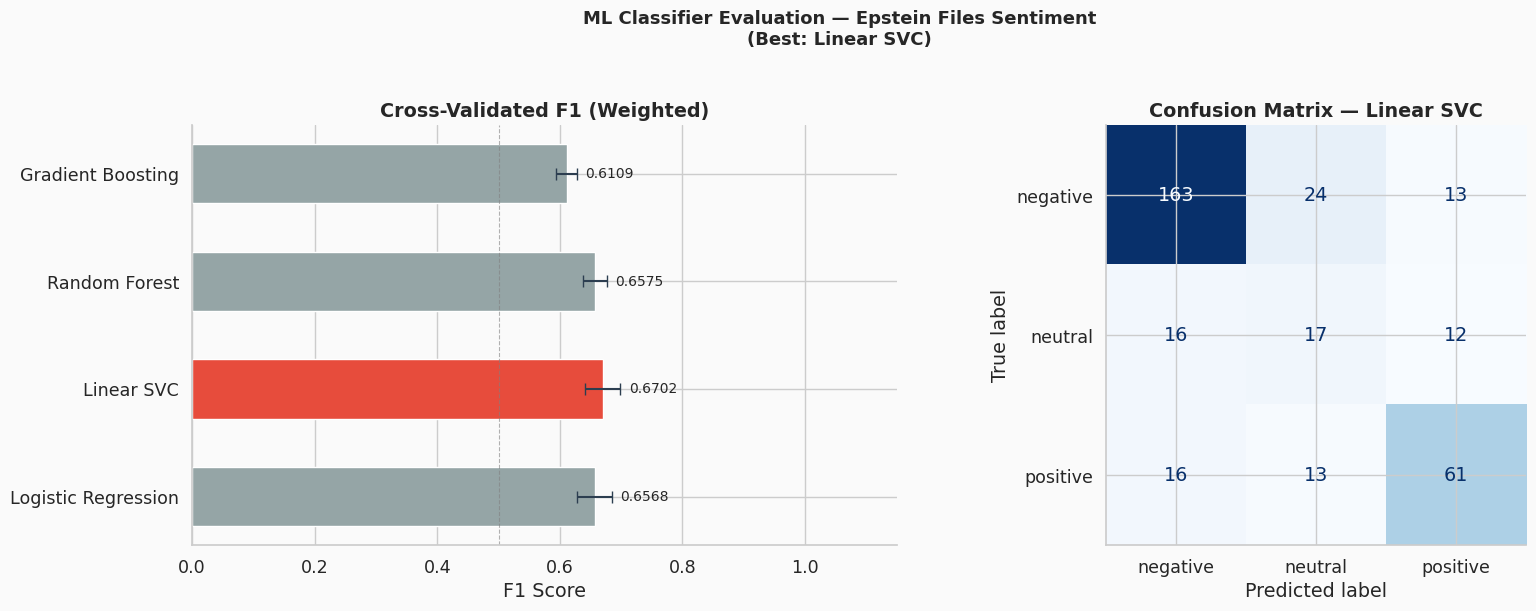

Saved → 13_ml_classifier_results.png


In [31]:
# ── Encode labels ───────────────────────────────────────────────────────────
le = LabelEncoder()
y  = le.fit_transform(df_ml["polarity"])   # negative=0, neutral=1, positive=2
classes = le.classes_

print(f"Classes : {list(classes)}")
print(f"Label distribution: { {c: int((y==i).sum()) for i,c in enumerate(classes)} }")

# Check minimum class size for stratified split
min_class = min((y == i).sum() for i in range(len(classes)))
if min_class < 10:
    print(f"\nWARNING: Smallest class has only {min_class} samples.")
    print("Classifier results may be unreliable. Collect more data for robust ML.")

# ── Train / test split ───────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain : {X_train.shape[0]:,}   Test : {X_test.shape[0]:,}")

# ── Models ───────────────────────────────────────────────────────────────────
MODELS = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, C=1.0,
                                                class_weight="balanced",
                                                random_state=42),
    "Linear SVC"          : LinearSVC(max_iter=2000, C=1.0,
                                       class_weight="balanced",
                                       random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=200,
                                                    class_weight="balanced",
                                                    random_state=42, n_jobs=-1),
    "Gradient Boosting"   : GradientBoostingClassifier(n_estimators=150,
                                                        learning_rate=0.1,
                                                        random_state=42),
}

results = {}
print("\n── Cross-validated F1 scores (5-fold StratifiedKFold) ──")
for name, model in MODELS.items():
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train,
                             cv=cv, scoring="f1_weighted", n_jobs=-1)
    results[name] = {"cv_mean": scores.mean(), "cv_std": scores.std()}
    print(f"  {name:<25}  F1 = {scores.mean():.4f} ± {scores.std():.4f}")

# ── Best model: full train + test eval ───────────────────────────────────────
best_name = max(results, key=lambda n: results[n]["cv_mean"])
print(f"\nBest model : {best_name}")

best_model = MODELS[best_name]
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=classes, zero_division=0))

# ── CV score comparison bar chart ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 6), facecolor="#fafafa")
fig.suptitle(f"ML Classifier Evaluation — Epstein Files Sentiment\n(Best: {best_name})",
             fontsize=13, fontweight="bold", y=1.02)

# Bar chart: model comparison
model_names  = list(results.keys())
means        = [results[n]["cv_mean"] for n in model_names]
stds         = [results[n]["cv_std"]  for n in model_names]
bar_colors   = ["#e74c3c" if n == best_name else "#95a5a6" for n in model_names]

bars = axes[0].barh(model_names, means, xerr=stds, color=bar_colors,
                    edgecolor="white", height=0.55,
                    error_kw=dict(elinewidth=1.5, ecolor="#2c3e50", capsize=4))
axes[0].bar_label(bars, fmt="%.4f", padding=6, fontsize=10)
axes[0].set_title("Cross-Validated F1 (Weighted)", fontweight="bold")
axes[0].set_xlabel("F1 Score")
axes[0].set_xlim(0, 1.15)
axes[0].axvline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

# Confusion matrix
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title(f"Confusion Matrix — {best_name}", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/13_ml_classifier_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 13_ml_classifier_results.png")


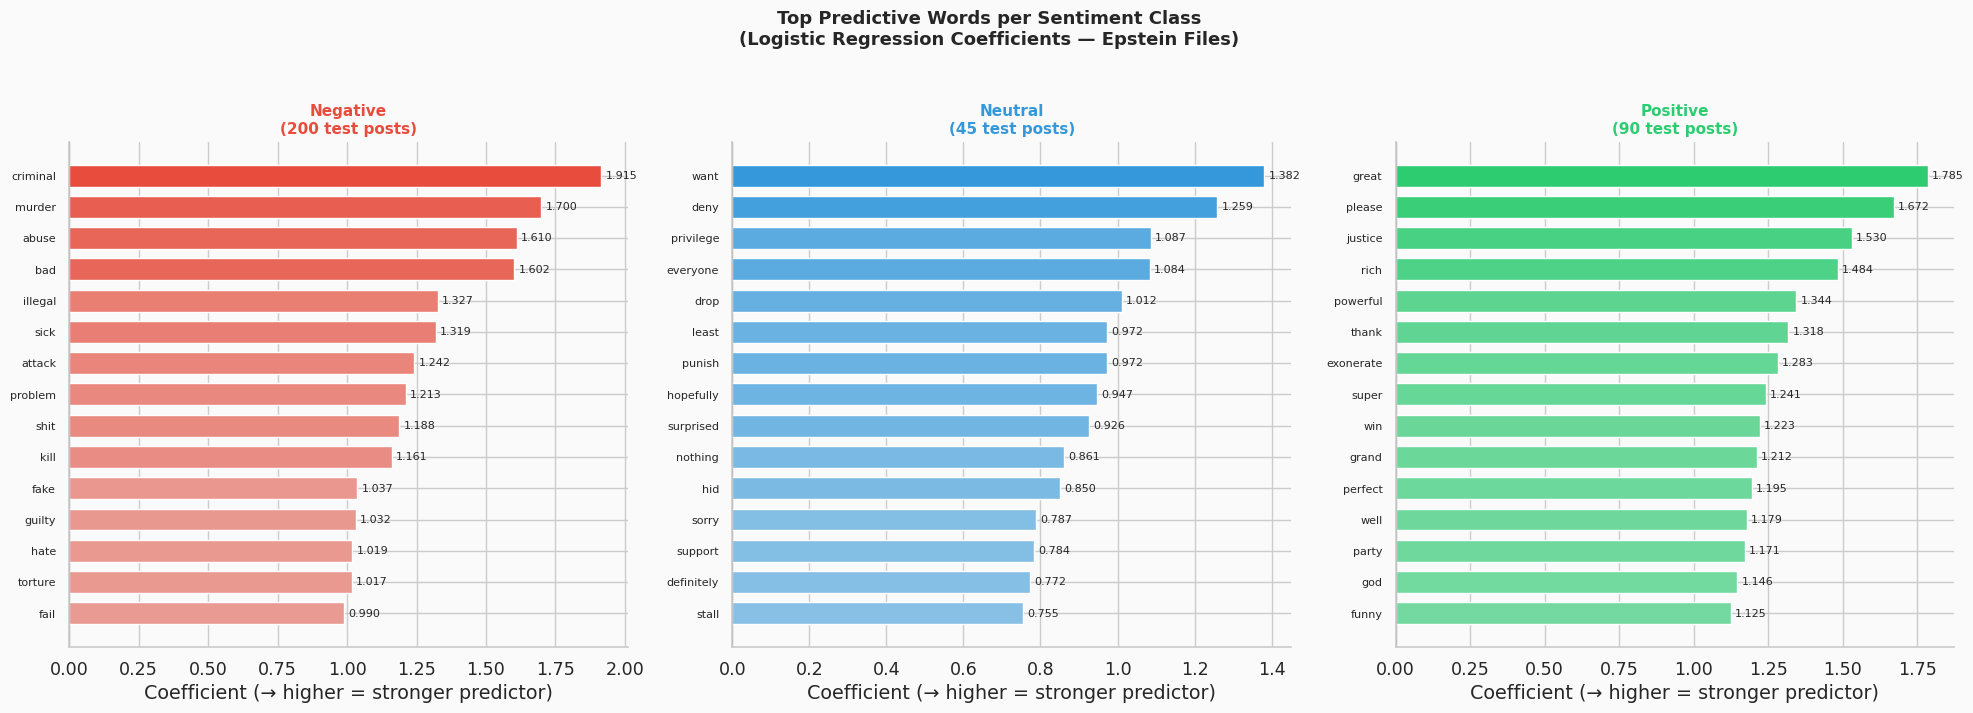

Saved → 14_feature_importance.png


In [32]:
# ── Top predictive features (Logistic Regression coefficients) ──────────────
# Even if LR wasn't the best model, its coefficients are the most interpretable
lr_model = MODELS["Logistic Regression"]
if not hasattr(lr_model, "coef_"):
    lr_model.fit(X_train, y_train)

TOP_FEAT = 15

fig, axes = plt.subplots(1, len(classes), figsize=(20, 7), facecolor="#fafafa")
fig.suptitle("Top Predictive Words per Sentiment Class\n(Logistic Regression Coefficients — Epstein Files)",
             fontsize=13, fontweight="bold", y=1.02)

for ax, (class_idx, class_name) in zip(axes, enumerate(classes)):
    coef      = lr_model.coef_[class_idx]
    top_pos   = coef.argsort()[-TOP_FEAT:][::-1]
    top_words = feature_names[top_pos]
    top_vals  = coef[top_pos]

    color = PALETTE.get(class_name, "#2c3e50")
    from matplotlib.colors import LinearSegmentedColormap
    cmap  = LinearSegmentedColormap.from_list("fade", ["#ecf0f1", color])
    bar_colors = [cmap(max(v,0) / max(top_vals.max(), 1e-9)) for v in top_vals]

    bars = ax.barh(top_words[::-1], top_vals[::-1],
                   color=bar_colors[::-1], edgecolor="white", height=0.7)
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
    ax.axvline(0, color="gray", linewidth=0.8)
    ax.set_title(f"{class_name.capitalize()}\n({(y_test==class_idx).sum()} test posts)",
                 fontweight="bold", color=color, fontsize=11)
    ax.set_xlabel("Coefficient (→ higher = stronger predictor)")
    ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/14_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 14_feature_importance.png")


## 9.5 Semantic Space Visualization (UMAP / t-SNE)

Projects the high-dimensional TF-IDF space into 2D to reveal **how posts cluster by sentiment and topic**. Tight, separated clusters = the model has strong signal. Overlapping clusters = ambiguous language.

SVD variance explained : 41.56%
Running UMAP...
UMAP projection complete. Shape: (1671, 2)


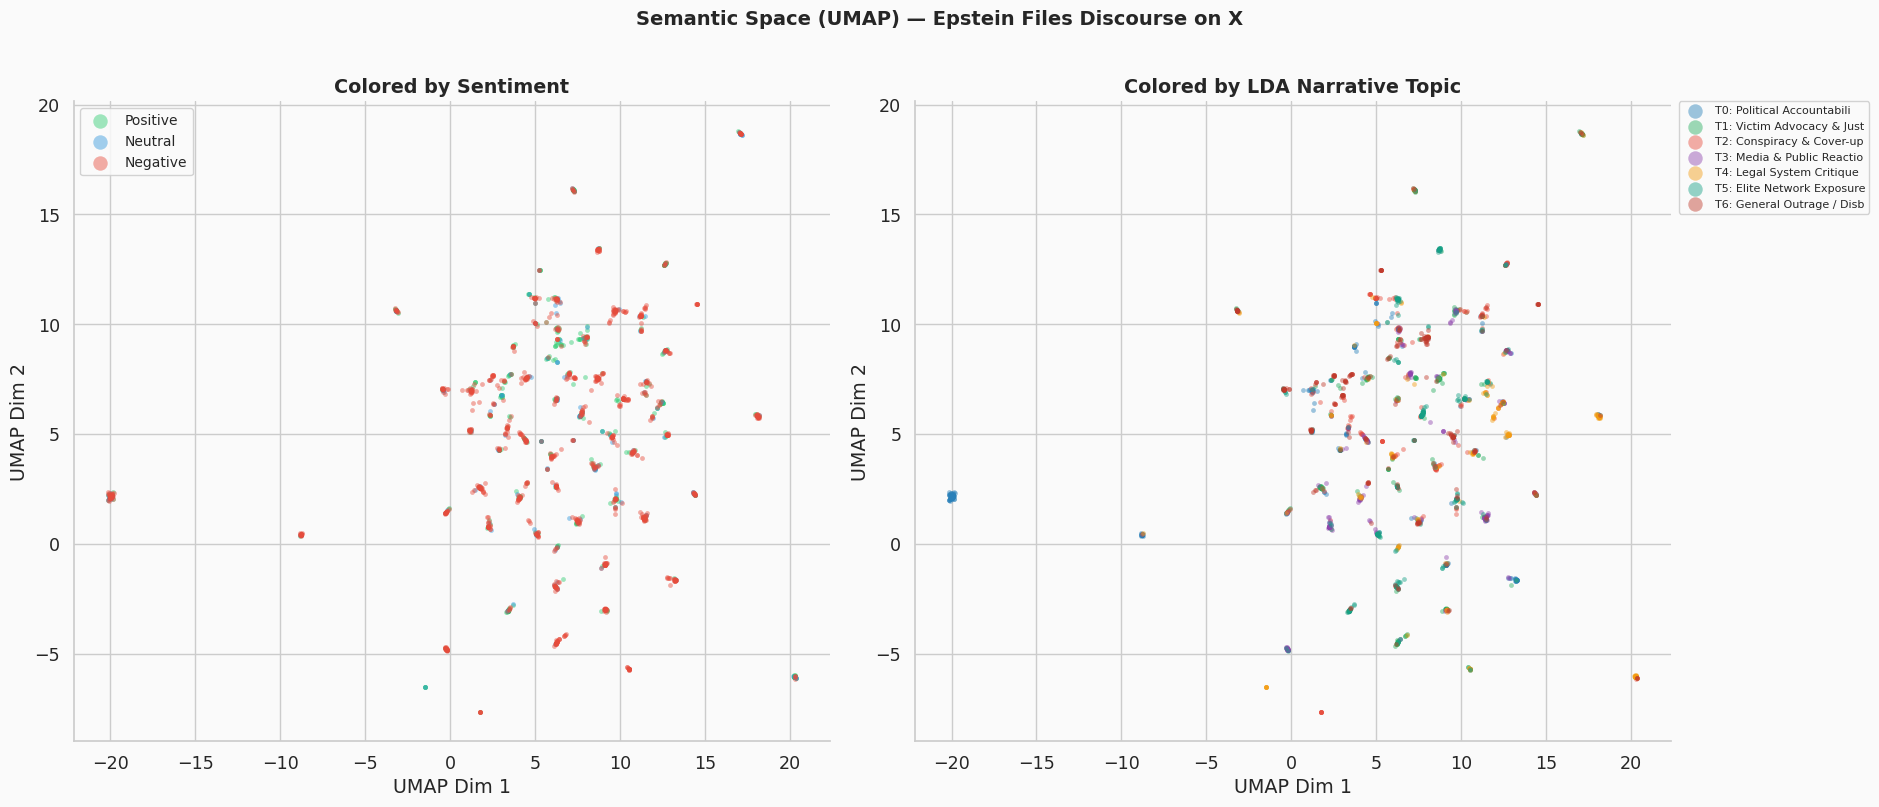

Saved → 15_semantic_space_umap.png


In [33]:
# Reduce to 50 dims with SVD first (speeds up UMAP/t-SNE dramatically)
svd = TruncatedSVD(n_components=50, random_state=42)
X_svd = svd.fit_transform(X_tfidf)
print(f"SVD variance explained : {svd.explained_variance_ratio_.sum():.2%}")

# ── 2D projection ────────────────────────────────────────────────────────────
if UMAP_AVAILABLE:
    print("Running UMAP...")
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1,
                        metric="cosine", random_state=42)
    X_2d    = reducer.fit_transform(X_svd)
    method_label = "UMAP"
else:
    print("Running t-SNE (UMAP not available)...")
    reducer = TSNE(n_components=2, perplexity=40, n_iter=1000,
                   metric="cosine", random_state=42, n_jobs=-1)
    X_2d    = reducer.fit_transform(X_svd)
    method_label = "t-SNE"

print(f"{method_label} projection complete. Shape: {X_2d.shape}")

# ── Plot: color by sentiment ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(19, 8), facecolor="#fafafa")
fig.suptitle(f"Semantic Space ({method_label}) — Epstein Files Discourse on X",
             fontsize=14, fontweight="bold", y=1.01)

# Panel 1: colored by sentiment
ax1 = axes[0]
for sentiment, color in PALETTE.items():
    mask = (df_ml["polarity"] == sentiment).values
    if mask.sum() == 0:
        continue
    ax1.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=color, label=sentiment.capitalize(),
                alpha=0.45, s=12, linewidths=0)
ax1.set_title("Colored by Sentiment", fontweight="bold")
ax1.set_xlabel(f"{method_label} Dim 1")
ax1.set_ylabel(f"{method_label} Dim 2")
legend1 = ax1.legend(markerscale=3, fontsize=10, framealpha=0.85)

# Panel 2: colored by LDA topic
ax2 = axes[1]
for topic_idx in range(N_TOPICS):
    mask  = (df_ml["lda_topic"] == topic_idx).values
    color = TOPIC_COLORS[topic_idx % len(TOPIC_COLORS)]
    label = f"T{topic_idx}: {NARRATIVE_LABELS.get(topic_idx,'Topic '+str(topic_idx))[:22]}"
    if mask.sum() == 0:
        continue
    ax2.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=color, label=label,
                alpha=0.45, s=12, linewidths=0)
ax2.set_title("Colored by LDA Narrative Topic", fontweight="bold")
ax2.set_xlabel(f"{method_label} Dim 1")
ax2.set_ylabel(f"{method_label} Dim 2")
ax2.legend(markerscale=3, fontsize=8, framealpha=0.85,
           loc="best", bbox_to_anchor=(1.01, 1), borderaxespad=0)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/15_semantic_space_{method_label.lower()}.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → 15_semantic_space_{method_label.lower()}.png")


## 9.6 Narrative Drift Over Time

Tracks **how the dominant narrative topics and sentiment language shifted** across the dataset's time range. As a media analyst, this reveals whether public discourse moved from shock/disbelief → political demands → conspiracy theories, etc.

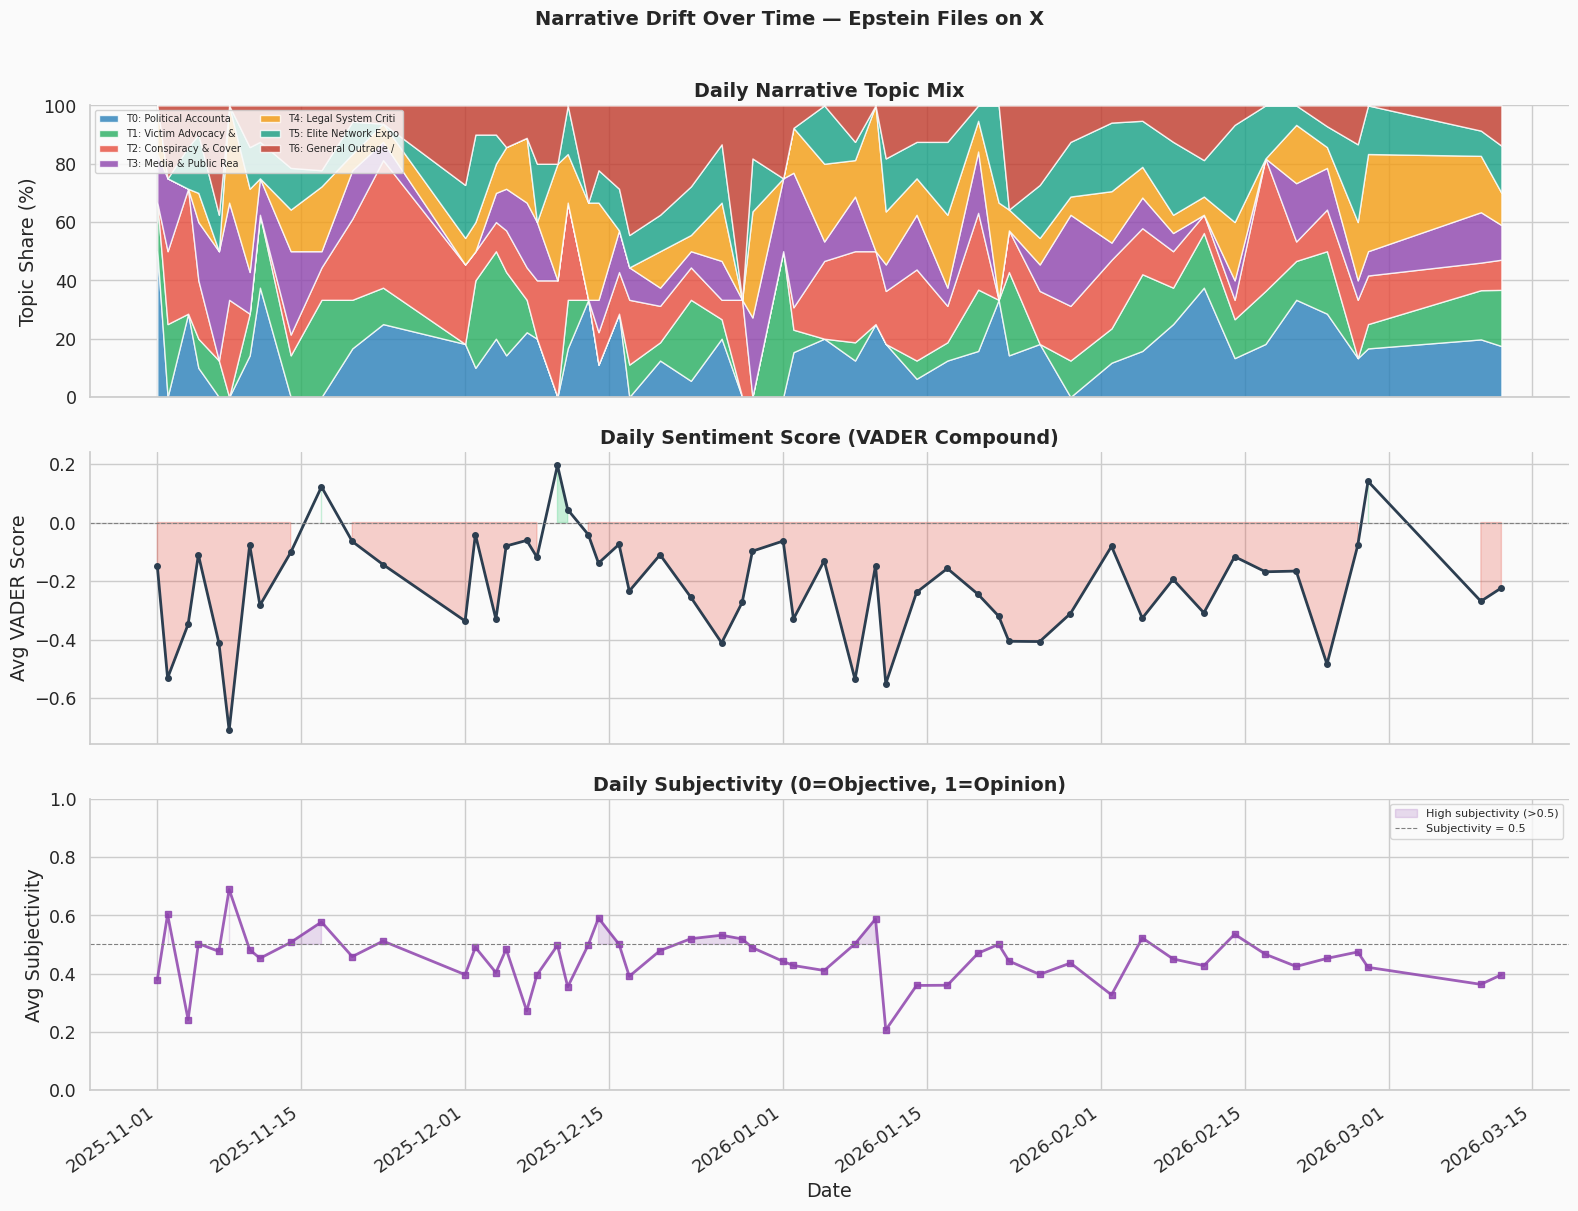

Saved → 16_narrative_drift.png


In [34]:
if "created_at" in df_ml.columns and df_ml["created_at"].notna().any():

    df_ml["date"] = pd.to_datetime(df_ml["created_at"], errors="coerce").dt.date
    df_ml_dated   = df_ml.dropna(subset=["date"]).copy()

    if len(df_ml_dated) < 20:
        print("Not enough dated posts for narrative drift analysis.")
    else:
        # ── Daily topic share ────────────────────────────────────────────────
        daily_topic = (
            df_ml_dated.groupby(["date", "lda_topic"])
            .size()
            .unstack(fill_value=0)
        )
        daily_topic_pct = daily_topic.div(daily_topic.sum(axis=1), axis=0).mul(100)

        # ── Daily mean polarity score ────────────────────────────────────────
        daily_score = df_ml_dated.groupby("date")["polarity_score"].mean()

        # ── Daily mean subjectivity (if available) ───────────────────────────
        has_subj = "subjectivity" in df_ml_dated.columns
        if has_subj:
            daily_subj = df_ml_dated.groupby("date")["subjectivity"].mean()

        fig_rows = 3 if has_subj else 2
        fig, axes = plt.subplots(fig_rows, 1,
                                  figsize=(16, 4 * fig_rows),
                                  sharex=True, facecolor="#fafafa")
        fig.suptitle("Narrative Drift Over Time — Epstein Files on X",
                     fontsize=14, fontweight="bold", y=1.01)

        # Stackplot: topic share over time
        ax1 = axes[0]
        colors_topics = [TOPIC_COLORS[i % len(TOPIC_COLORS)] for i in range(N_TOPICS)]
        labels_topics = [
            f"T{i}: {NARRATIVE_LABELS.get(i,'Topic '+str(i))[:18]}"
            for i in range(N_TOPICS)
        ]

        plot_cols = [c for c in range(N_TOPICS) if c in daily_topic_pct.columns]
        ax1.stackplot(
            daily_topic_pct.index,
            *[daily_topic_pct[c].fillna(0) for c in plot_cols],
            labels=[labels_topics[c] for c in plot_cols],
            colors=[colors_topics[c] for c in plot_cols],
            alpha=0.80,
        )
        ax1.set_ylabel("Topic Share (%)")
        ax1.set_title("Daily Narrative Topic Mix", fontweight="bold")
        ax1.set_ylim(0, 100)
        ax1.legend(loc="upper left", fontsize=7, ncol=2,
                   framealpha=0.85)

        # Line: average VADER score over time
        ax2 = axes[1]
        ax2.plot(daily_score.index, daily_score.values,
                 color="#2c3e50", linewidth=2, marker="o", markersize=4)
        ax2.fill_between(daily_score.index, 0, daily_score.values,
                         where=(daily_score.values >= 0),
                         color=PALETTE["positive"], alpha=0.25)
        ax2.fill_between(daily_score.index, 0, daily_score.values,
                         where=(daily_score.values < 0),
                         color=PALETTE["negative"], alpha=0.25)
        ax2.axhline(0, color="gray", linestyle="--", linewidth=0.8)
        ax2.set_ylabel("Avg VADER Score")
        ax2.set_title("Daily Sentiment Score (VADER Compound)", fontweight="bold")

        if has_subj:
            ax3 = axes[2]
            ax3.plot(daily_subj.index, daily_subj.values,
                     color="#8e44ad", linewidth=2, marker="s", markersize=4, alpha=0.85)
            ax3.fill_between(daily_subj.index, 0.5, daily_subj.values,
                             where=(daily_subj.values >= 0.5),
                             color="#8e44ad", alpha=0.18,
                             label="High subjectivity (>0.5)")
            ax3.axhline(0.5, color="gray", linestyle="--", linewidth=0.8,
                        label="Subjectivity = 0.5")
            ax3.set_ylabel("Avg Subjectivity")
            ax3.set_title("Daily Subjectivity (0=Objective, 1=Opinion)",
                          fontweight="bold")
            ax3.set_ylim(0, 1)
            ax3.legend(fontsize=8)
            ax3.set_xlabel("Date")
        else:
            axes[-1].set_xlabel("Date")

        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()
        plt.savefig(f"{OUTPUT_DIR}/16_narrative_drift.png", dpi=150, bbox_inches="tight")
        plt.show()
        print("Saved → 16_narrative_drift.png")

else:
    print("No valid datetime column — narrative drift chart skipped.")
    print("Set DATE_COLUMN in Section 2 to enable this visualization.")


## 9.7 ML Analyst Summary Report

Consolidated findings from all NLP/ML modules — ready to copy into a media briefing.

In [35]:
print("=" * 65)
print("   NLP / ML ANALYST REPORT — EPSTEIN FILES DISCOURSE ON X")
print("=" * 65)

print(f"\nDataset     : {CSV_PATH}")
print(f"Total posts : {len(df_ml):,} (post-cleaning ML-ready corpus)")

print("\n── Sentiment Distribution ──────────────────────────────────")
for label in ["positive", "neutral", "negative"]:
    n   = (df_ml["polarity"] == label).sum()
    pct = n / len(df_ml) * 100
    bar = "█" * int(pct / 2)
    print(f"  {label.capitalize():<10} {n:>6,}  ({pct:5.1f}%)  {bar}")

print("\n── TF-IDF: Top Discriminative Terms ───────────────────────")
for sentiment in ["positive", "neutral", "negative"]:
    mask  = (df_ml["polarity"] == sentiment).values
    sub   = X_tfidf[mask]
    if sub.shape[0] == 0:
        print(f"  {sentiment.capitalize():<10} : no posts")
        continue
    mean_sc = np.asarray(sub.mean(axis=0)).flatten()
    top5    = feature_names[mean_sc.argsort()[-5:][::-1]]
    print(f"  {sentiment.capitalize():<10} : {', '.join(top5)}")

print("\n── LDA Narrative Topics ────────────────────────────────────")
for t in range(N_TOPICS):
    n     = (df_ml["lda_topic"] == t).sum()
    pct   = n / len(df_ml) * 100
    label = NARRATIVE_LABELS.get(t, f"Topic {t}")
    # top 5 words for this topic
    top5w = count_features[lda.components_[t].argsort()[-5:][::-1]]
    print(f"  T{t} [{label:<30}] {n:>5,} ({pct:4.1f}%)  [{', '.join(top5w)}]")

print("\n── ML Classifier (Best Model) ──────────────────────────────")
print(f"  Model       : {best_name}")
print(f"  CV F1       : {results[best_name]['cv_mean']:.4f} ± {results[best_name]['cv_std']:.4f}")
cr = classification_report(y_test, y_pred, target_names=classes,
                           output_dict=True, zero_division=0)
for cls in classes:
    row = cr.get(cls, {})
    print(f"  {cls.capitalize():<10} — precision {row.get('precision',0):.3f}  "
          f"recall {row.get('recall',0):.3f}  f1 {row.get('f1-score',0):.3f}")

if "subjectivity" in df_ml.columns:
    print("\n── Subjectivity (TextBlob) ─────────────────────────────────")
    for label in ["positive", "neutral", "negative"]:
        sub_scores = df_ml[df_ml["polarity"]==label]["subjectivity"]
        if sub_scores.empty: continue
        print(f"  {label.capitalize():<10} — mean subjectivity {sub_scores.mean():.3f}")

print("\n── Output Files ────────────────────────────────────────────")
for i, fname in enumerate([
    "10_tfidf_distinctive_terms.png",
    "11_lda_topic_modeling.png",
    "12_topic_cosine_similarity.png",
    "13_ml_classifier_results.png",
    "14_feature_importance.png",
    "15_semantic_space_*.png",
    "16_narrative_drift.png (if datetime available)",
], start=1):
    print(f"  {i}. {fname}")

print("=" * 65)


   NLP / ML ANALYST REPORT — EPSTEIN FILES DISCOURSE ON X

Dataset     : Epstein_Files_Concatenated.csv
Total posts : 1,671 (post-cleaning ML-ready corpus)

── Sentiment Distribution ──────────────────────────────────
  Positive      448  ( 26.8%)  █████████████
  Neutral       227  ( 13.6%)  ██████
  Negative      996  ( 59.6%)  █████████████████████████████

── TF-IDF: Top Discriminative Terms ───────────────────────
  Positive   : justice, well, good, please, truth
  Neutral    : want, nothing, never, arrest, everyone
  Negative   : scandal, arrest, criminal, hide, distraction

── LDA Narrative Topics ────────────────────────────────────
  T0 [Political Accountability      ]   286 (17.1%)  [arrest, everyone, serious, fuck, pay]
  T1 [Victim Advocacy & Justice     ]   280 (16.8%)  [distraction, want, crime, criminal, kill]
  T2 [Conspiracy & Cover-up         ]   212 (12.7%)  [nothing, good, murder, prison, pardon]
  T3 [Media & Public Reaction       ]   214 (12.8%)  [stop, bad, scand

---
# 10. Export


In [36]:
export_cols = [
    "text",
    *([ "created_at"] if "created_at" in df.columns else []),
    "polarity",
    "polarity_score",
    "vader_pos",
    "vader_neu",
    "vader_neg",
    "char_length",
    "word_length",
    "avg_word_len",
    "subjectivity",
    "readability",
    "pos_adj_ratio",
    "pos_verb_ratio",
    "pos_noun_ratio",
    "pos_adv_ratio",
]

df_export = df[[c for c in export_cols if c in df.columns]].copy()

# Add time features if datetime is present
if "created_at" in df_export.columns:
    created = pd.to_datetime(df_export["created_at"], errors="coerce")
    df_export["date"]        = created.dt.date
    df_export["hour"]        = created.dt.hour
    df_export["day_of_week"] = created.dt.day_name()

EXPORT_PATH = f"{OUTPUT_DIR}/sentiment_analysis_final.csv"
df_export.to_csv(EXPORT_PATH, index=False)

print(f"Exported {len(df_export):,} rows  →  {EXPORT_PATH}")
print(f"Columns : {list(df_export.columns)}")
df_export.head(3)

Exported 2,098 rows  →  outputs/sentiment_analysis_final.csv
Columns : ['text', 'created_at', 'polarity', 'polarity_score', 'vader_pos', 'vader_neu', 'vader_neg', 'char_length', 'word_length', 'avg_word_len', 'subjectivity', 'readability', 'pos_adj_ratio', 'pos_verb_ratio', 'pos_noun_ratio', 'pos_adv_ratio', 'date', 'hour', 'day_of_week']


,text,created_at,polarity,polarity_score,vader_pos,vader_neu,vader_neg,char_length,word_length,avg_word_len,subjectivity,readability,pos_adj_ratio,pos_verb_ratio,pos_noun_ratio,pos_adv_ratio,date,hour,day_of_week
0,@sploder6 @DavidNachman3 @59SouthLee @BackupJeffx Epstein was Jewish. The emails show his claimed Rothschild links and social ties with figures like Baron de Rothschild. 2026 file releases document his network donations to pro-Israel groups and associations with elites of varied backgrounds including non-Jews like Clinton,2026-03-10 23:59:06,neutral,0.0000,0.0000,0.0000,0.0000,324,0,0.00,0.0333,40.05,0.0000,0.0,0.0000,0.0,2026-03-10,23,Tuesday
1,@Israel2252 Not all Jews but all Zionists are ruining the world. Example; Epstein file.,2026-03-10 23:58:47,negative,-0.4511,0.0000,0.4698,0.5302,88,1,4.00,0.0000,66.79,0.0000,0.0,1.0000,0.0,2026-03-10,23,Tuesday
2,@Parodyjeffx # I @realDonaldTrump wants the Americans to treat me the way the North Korean people treat their dictator Kim Jong Un # American will once U clear ur name from Epstein file @AnaKasparian @jacksonhinklle @RealCandaceO @RealScottRitter @IlhanMN @Lawrence,2026-03-10 23:56:45,positive,0.7467,0.5998,0.4002,0.0000,265,3,4.67,0.1611,4.65,0.6667,0.0,0.3333,0.0,2026-03-10,23,Tuesday


---
# 11. Summary Report

In [37]:
print("=" * 58)
print("        SENTIMENT ANALYSIS — SUMMARY REPORT")
print("=" * 58)

print(f"Dataset         : {CSV_PATH}")
print(f"Total posts     : {len(df):,}")

print("Sentiment Distribution:")
for label in ["positive", "neutral", "negative"]:
    n   = (df["polarity"] == label).sum()
    pct = n / len(df) * 100
    bar = "█" * int(pct / 2)
    print(f"  {label.capitalize():<10} {n:>6,}  ({pct:5.1f}%)  {bar}")

print("VADER Score Stats:")
print(f"  Mean   : {df['polarity_score'].mean():.4f}")
print(f"  Median : {df['polarity_score'].median():.4f}")
print(f"  Std    : {df['polarity_score'].std():.4f}")
print(f"  Min    : {df['polarity_score'].min():.4f}")
print(f"  Max    : {df['polarity_score'].max():.4f}")

print("Text Length Stats (clean tokens):")
print(f"  Avg word count : {df['word_length'].mean():.1f}")
print(f"  Avg word len   : {df['avg_word_len'].mean():.2f} chars")

print("Outputs saved to:", OUTPUT_DIR)
print(f"  - sentiment_analysis_final.csv")
print(f"  - negative_posts_sample.csv")
for i in range(1, 10):
    fname = f"{i:02d}_*.png"
    print(f"  - {fname}")

print("=" * 58)

        SENTIMENT ANALYSIS — SUMMARY REPORT
Dataset         : Epstein_Files_Concatenated.csv
Total posts     : 2,098
Sentiment Distribution:
  Positive      448  ( 21.4%)  ██████████
  Neutral       654  ( 31.2%)  ███████████████
  Negative      996  ( 47.5%)  ███████████████████████
VADER Score Stats:
  Mean   : -0.1780
  Median : -0.0835
  Std    : 0.4465
  Min    : -0.9803
  Max    : 0.9260
Text Length Stats (clean tokens):
  Avg word count : 2.2
  Avg word len   : 4.66 chars
Outputs saved to: outputs
  - sentiment_analysis_final.csv
  - negative_posts_sample.csv
  - 01_*.png
  - 02_*.png
  - 03_*.png
  - 04_*.png
  - 05_*.png
  - 06_*.png
  - 07_*.png
  - 08_*.png
  - 09_*.png
